In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
# Cell 1: Thiết lập môi trường và phụ thuộc

# Cài đặt các thư viện cần thiết 
# !pip install -q torch torchvision torchaudio
# !pip install -q timm scikit-learn pandas matplotlib seaborn

# Import các thư viện lõi
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm

# Import các thư viện tiện ích
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
import random
from PIL import Image

import os
from pathlib import Path
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from datetime import datetime
import random
import numpy as np
from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T

# Kiểm tra khả dụng của GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

# Thiết lập random seed để tái lập kết quả
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("\nThiết lập môi trường hoàn tất!")

Using device: cpu

Thiết lập môi trường hoàn tất!


In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
DATA_DIR = Path('data')

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
def ensure_dataset_exists(data_dir: Path) -> None:
    """Kiểm tra dataset tồn tại."""
    if not data_dir.exists():
        raise FileNotFoundError(
            f"Dataset không tìm thấy tại {data_dir}\n"
            "Hãy thêm 'ipythonx/mvtec-ad' vào phần input trong Kaggle Notebook settings"
        )
    else:
        print("Dataset đã tồn tại và sẵn sàng để sử dụng")
ensure_dataset_exists(DATA_DIR)

Dataset đã tồn tại và sẵn sàng để sử dụng


In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
def list_categories(data_dir: Path) -> list[str]:
    cats = sorted([d for d in os.listdir(data_dir) if os.path.isdir(data_dir / d)])
    return cats
cats = list_categories(DATA_DIR)
print(cats)

['capsule']


In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
def get_category_stats(data_dir: Path, category: str) -> dict:
    """Tính thống kê cho 1 danh mục."""
    category_path = data_dir / category

    # Train normal
    train_path = category_path / 'train' / 'good'
    train_count = len(list(train_path.glob('*.png'))) if train_path.exists() else 0

    # Test normal
    test_path = category_path / 'test'
    test_good_path = test_path / 'good'
    test_normal = len(list(test_good_path.glob('*.png'))) if test_good_path.exists() else 0

    # Test anomaly
    anomaly_types = []
    test_anomaly = 0
    if test_path.exists():
        anomaly_types = [
            d.name for d in test_path.iterdir()
            if d.is_dir() and d.name != 'good'
        ]
        test_anomaly = sum(len(list((test_path / anom).glob('*.png'))) for anom in anomaly_types)

    return {
        'Category': category,
        'Train (Normal)': train_count,
        'Test (Normal)': test_normal,
        'Test (Anomaly)': test_anomaly,
        'Anomaly Types': len(anomaly_types),
        'Anomaly Type Names': anomaly_types,  # thêm để tiện xem
    }

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
capsule_stats = get_category_stats(DATA_DIR, "capsule") 
capsule_stats_df = pd.DataFrame([{
    "Category": capsule_stats["Category"],
    "Train (Normal)": capsule_stats["Train (Normal)"],
    "Test (Normal)": capsule_stats["Test (Normal)"],
    "Test (Anomaly)": capsule_stats["Test (Anomaly)"],
    "Anomaly Types": capsule_stats["Anomaly Types"],
}])

display(capsule_stats_df)
print("Total categories:", len(cats))
print("Total train:", int(capsule_stats_df["Train (Normal)"].sum()))
print("Total test:", int((capsule_stats_df["Test (Normal)"] + capsule_stats_df["Test (Anomaly)"]).sum()))

,Category,Train (Normal),Test (Normal),Test (Anomaly),Anomaly Types
0,capsule,219,23,109,5


Total categories: 1
Total train: 219
Total test: 132


In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
def show_sample_image(data_dir: Path, category: str, split: str = "train", subdir: str = "good") -> None:
    """Hiển thị 1 ảnh mẫu của category (mặc định: train/good)."""
    sample_dir = data_dir / category / split / subdir
    imgs = list(sample_dir.glob('*.png')) if sample_dir.exists() else []
    if not imgs:
        print(f"Không tìm thấy ảnh .png tại: {sample_dir}")
        return

    img_path = imgs[0]
    img = Image.open(img_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Mẫu: {category} ({split}/{subdir})")
    plt.axis('off')
    plt.show()
    print(f"File: {img_path.name}")
    print(f"Kích thước ảnh: {img.size}")

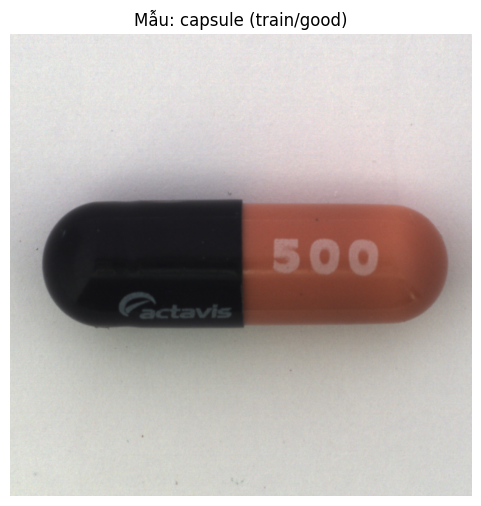

File: 015.png
Kích thước ảnh: (1000, 1000)


In [8]:
# --- [CELL 7]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
show_sample_image(DATA_DIR, "capsule", split="train", subdir="good")

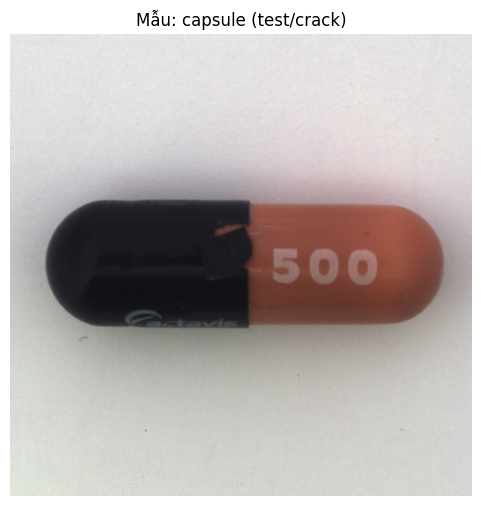

File: 015.png
Kích thước ảnh: (1000, 1000)


In [9]:
# --- [CELL 8]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 9}
show_sample_image(DATA_DIR, "capsule", split="test", subdir="crack")

Đang kiểm tra cấu trúc bộ dữ liệu...
Số danh mục tìm thấy: 1
Danh mục: ['capsule']

Thống kê bộ dữ liệu:
--------------------------------------------------------------------------------
capsule         | Train:  219 | Test Normal:  23 | Test Anomaly: 109 | Số loại bất thường: 5

TỔNG SỐ DANH MỤC: 1
TỔNG SỐ MẪU TRAIN: 219
TỔNG SỐ MẪU TEST: 132

Ảnh mẫu từ danh mục 'capsule':


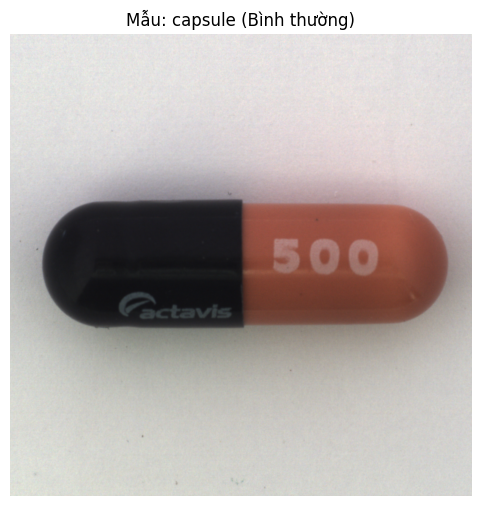

Kích thước ảnh: (1000, 1000)

Chuẩn bị dữ liệu hoàn tất!
Đường dẫn dữ liệu: data
Hoàn thành lúc: 2026-05-11 11:08:17


In [10]:
# --- [CELL 9]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 10}
# Cell 2: Chuẩn bị dữ liệu (Kaggle Input)

import os
from pathlib import Path
from datetime import datetime

# Dùng thư mục input của Kaggle (cần thêm dataset vào phần input)
DATA_DIR = Path('data')

# Nếu không dùng input, bỏ comment bên dưới để tải về:
# DATA_DIR = Path('/kaggle/working/mvtec_ad')
# !kaggle datasets download -d ipythonx/mvtec-ad -p {DATA_DIR} --unzip

# Kiểm tra cấu trúc bộ dữ liệu
print("Đang kiểm tra cấu trúc bộ dữ liệu...")
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Dataset không tìm thấy tại {DATA_DIR}\n"
        "Hãy thêm 'ipythonx/mvtec-ad' vào phần input trong Kaggle Notebook settings"
    )

categories = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(DATA_DIR / d)])
print(f"Số danh mục tìm thấy: {len(categories)}")
print(f"Danh mục: {categories}")

# Hiển thị thống kê dữ liệu cho từng danh mục
print("\nThống kê bộ dữ liệu:")
print("-" * 80)
dataset_stats = []

for category in categories:
    category_path = DATA_DIR / category
    
    # Đếm ảnh train (mẫu bình thường)
    train_path = category_path / 'train' / 'good'
    train_count = len(list(train_path.glob('*.png'))) if train_path.exists() else 0
    
    # Đếm ảnh test (bình thường + bất thường)
    test_path = category_path / 'test'
    test_normal = len(list((test_path / 'good').glob('*.png'))) if (test_path / 'good').exists() else 0
    
    # Đếm số loại bất thường
    anomaly_types = [d.name for d in test_path.iterdir() if d.is_dir() and d.name != 'good'] if test_path.exists() else []
    test_anomaly = sum([len(list((test_path / anom).glob('*.png'))) for anom in anomaly_types])
    
    dataset_stats.append({
        'Category': category,
        'Train (Normal)': train_count,
        'Test (Normal)': test_normal,
        'Test (Anomaly)': test_anomaly,
        'Anomaly Types': len(anomaly_types)
    })
    
    print(
        f"{category:15s} | "
        f"Train: {train_count:4d} | "
        f"Test Normal: {test_normal:3d} | "
        f"Test Anomaly: {test_anomaly:3d} | "
        f"Số loại bất thường: {len(anomaly_types)}"
    )

# Chuyển sang DataFrame để quan sát dễ hơn
stats_df = pd.DataFrame(dataset_stats)
print("\n" + "=" * 80)
print(f"TỔNG SỐ DANH MỤC: {len(categories)}")
print(f"TỔNG SỐ MẪU TRAIN: {stats_df['Train (Normal)'].sum()}")
print(f"TỔNG SỐ MẪU TEST: {stats_df['Test (Normal)'].sum() + stats_df['Test (Anomaly)'].sum()}")
print("=" * 80)

# Hiển thị một ảnh mẫu từ danh mục đầu tiên
print(f"\nẢnh mẫu từ danh mục '{categories[0]}':")
sample_category = DATA_DIR / categories[0] / 'train' / 'good'
sample_images = list(sample_category.glob('*.png'))
if sample_images:
    sample_img = Image.open(sample_images[0])
    plt.figure(figsize=(6, 6))
    plt.imshow(sample_img)
    plt.title(f"Mẫu: {categories[0]} (Bình thường)")
    plt.axis('off')
    plt.show()
    print(f"Kích thước ảnh: {sample_img.size}")

print("\nChuẩn bị dữ liệu hoàn tất!")
print(f"Đường dẫn dữ liệu: {DATA_DIR}")
print(f"Hoàn thành lúc: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

In [11]:
# --- [CELL 10]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 11}
def get_paths_one_category(data_dir: Path, category: str):
    """Trả về dict các path quan trọng của 1 category."""
    cat_dir = data_dir / category
    return {
        "cat_dir": cat_dir,
        "train_good": cat_dir / "train" / "good",
        "test_good": cat_dir / "test" / "good",
        "test_dir": cat_dir / "test",
        "gt_dir": cat_dir / "ground_truth",
    }

def list_defect_types(data_dir: Path, category: str):
    """Liệt kê các defect type (subfolder trong test, bỏ good)."""
    p = get_paths_one_category(data_dir, category)["test_dir"]
    if not p.exists():
        return []
    return sorted([d.name for d in p.iterdir() if d.is_dir() and d.name != "good"])

def count_png(folder: Path):
    return len(list(folder.glob("*.png"))) if folder.exists() else 0

# =======================
# 2) Stats
# =======================
def get_category_stats_one(data_dir: Path, category: str):
    """Thống kê train/test cho 1 category."""
    paths = get_paths_one_category(data_dir, category)

    train_count = count_png(paths["train_good"])
    test_normal = count_png(paths["test_good"])

    defect_types = list_defect_types(data_dir, category)
    test_anomaly = sum(count_png(paths["test_dir"] / d) for d in defect_types)

    return {
        "Category": category,
        "Train (Normal)": train_count,
        "Test (Normal)": test_normal,
        "Test (Anomaly)": test_anomaly,
        "Anomaly Types": len(defect_types),
        "Anomaly Type Names": defect_types,
    }

def print_category_stats(stats: dict):
    print(
        f"{stats['Category']:15s} | "
        f"Train: {stats['Train (Normal)']:4d} | "
        f"Test Normal: {stats['Test (Normal)']:3d} | "
        f"Test Anomaly: {stats['Test (Anomaly)']:3d} | "
        f"Số loại bất thường: {stats['Anomaly Types']}"
    )

# =======================
# 3) Visualization: samples
# =======================
def _open_first_png(folder: Path):
    imgs = list(folder.glob("*.png")) if folder.exists() else []
    return Image.open(imgs[0]) if imgs else None, (imgs[0] if imgs else None)

def load_sample_images(
    data_dir: Path,
    category: str,
    n_anom_types: int = 2,
    defect_type: str | None = None,
):
    """
    Load 1 ảnh train/good, 1 ảnh test/good,
    và ảnh anomaly theo:
      - defect_type nếu cung cấp,
      - hoặc top n_anom_types defect types.
    """
    paths = get_paths_one_category(data_dir, category)

    train_img, train_path = _open_first_png(paths["train_good"])
    test_img, test_path = _open_first_png(paths["test_good"])

    anomalies = []
    if defect_type is not None:
        img, p = _open_first_png(paths["test_dir"] / defect_type)
        if img is not None:
            anomalies.append((defect_type, img, p))
    else:
        defect_types = list_defect_types(data_dir, category)[:n_anom_types]
        for dt in defect_types:
            img, p = _open_first_png(paths["test_dir"] / dt)
            if img is not None:
                anomalies.append((dt, img, p))

    return {
        "train_good": (train_img, train_path),
        "test_good": (test_img, test_path),
        "anomalies": anomalies,  # list of (defect_type, PIL.Image, path)
    }

def plot_samples_one_category(
    data_dir: Path,
    category: str,
    n_anom_types: int = 2,
    defect_type: str | None = None,
):
    """Vẽ 1 hàng 4 cột: train good | test good | anomaly1 | anomaly2."""
    samples = load_sample_images(
        data_dir=data_dir,
        category=category,
        n_anom_types=n_anom_types,
        defect_type=defect_type,
    )

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # col0 train
    img, p = samples["train_good"]
    if img is not None:
        axes[0].imshow(img)
        axes[0].set_title(f"{category}\nTrain Normal", fontsize=10)
    axes[0].axis("off")

    # col1 test good
    img, p = samples["test_good"]
    if img is not None:
        axes[1].imshow(img)
        axes[1].set_title(f"{category}\nTest Normal", fontsize=10)
    axes[1].axis("off")

    # col2-3 anomalies
    anomalies = samples["anomalies"]
    for j in range(2):
        ax = axes[2 + j]
        if j < len(anomalies):
            dt, img, p = anomalies[j]
            ax.imshow(img)
            ax.set_title(f"{category}\n{dt}", fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    return samples

# =======================
# 4) Image dimension (single-category)
# =======================
def get_image_dimension_one(data_dir: Path, category: str):
    """Lấy kích thước ảnh mẫu từ train/good."""
    paths = get_paths_one_category(data_dir, category)
    img, p = _open_first_png(paths["train_good"])
    if img is None:
        return None
    w, h = img.size
    return {"Category": category, "Width": w, "Height": h, "Aspect Ratio": w / h, "Mode": img.mode, "Sample": str(p.name)}

def print_image_dimension(dim: dict | None):
    if dim is None:
        print("Không lấy được kích thước ảnh (không có ảnh train/good).")
        return
    print(f"{dim['Category']:15s} | {dim['Width']}x{dim['Height']} | Tỉ lệ: {dim['Aspect Ratio']:.2f} | Mode: {dim['Mode']} | Sample: {dim['Sample']}")

# =======================
# 5) Defect distribution (single-category)
# =======================
def defect_distribution_one(data_dir: Path, category: str):
    """Trả về list (defect_type, count) trong 1 category."""
    paths = get_paths_one_category(data_dir, category)
    defect_types = list_defect_types(data_dir, category)
    counts = [(dt, count_png(paths["test_dir"] / dt)) for dt in defect_types]
    counts.sort(key=lambda x: x[1], reverse=True)
    return counts

def plot_defect_distribution_one(data_dir: Path, category: str, topk: int = 10):
    """Vẽ bar chart top-k defect types trong 1 category."""
    dist = defect_distribution_one(data_dir, category)
    top = dist[:topk]
    if not top:
        print("Không có defect types để vẽ.")
        return dist

    names = [d[0] for d in top]
    counts = [d[1] for d in top]

    plt.figure(figsize=(12, 5))
    plt.barh(names, counts)
    plt.xlabel("Số lượng mẫu")
    plt.title(f"Top {len(top)} loại lỗi phổ biến nhất trong '{category}'")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    return dist

# =======================
# 6) One-call pipeline
# =======================
def explore_one_category(
    data_dir: Path,
    category: str,
    defect_type: str | None = None,
    n_anom_types: int = 2,
    topk_defects: int = 10,
):
    print(f"=== Explore category: {category} ===")
    stats = get_category_stats_one(data_dir, category)
    print_category_stats(stats)

    print("\nẢnh mẫu:")
    plot_samples_one_category(data_dir, category, n_anom_types=n_anom_types, defect_type=defect_type)

    print("\nKích thước ảnh:")
    dim = get_image_dimension_one(data_dir, category)
    print_image_dimension(dim)

    print("\nPhân bố defect types:")
    dist = plot_defect_distribution_one(data_dir, category, topk=topk_defects)

    print("\nHoàn thành lúc:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
    return stats, dim, dist

=== Explore category: capsule ===
capsule         | Train:  219 | Test Normal:  23 | Test Anomaly: 109 | Số loại bất thường: 5

Ảnh mẫu:


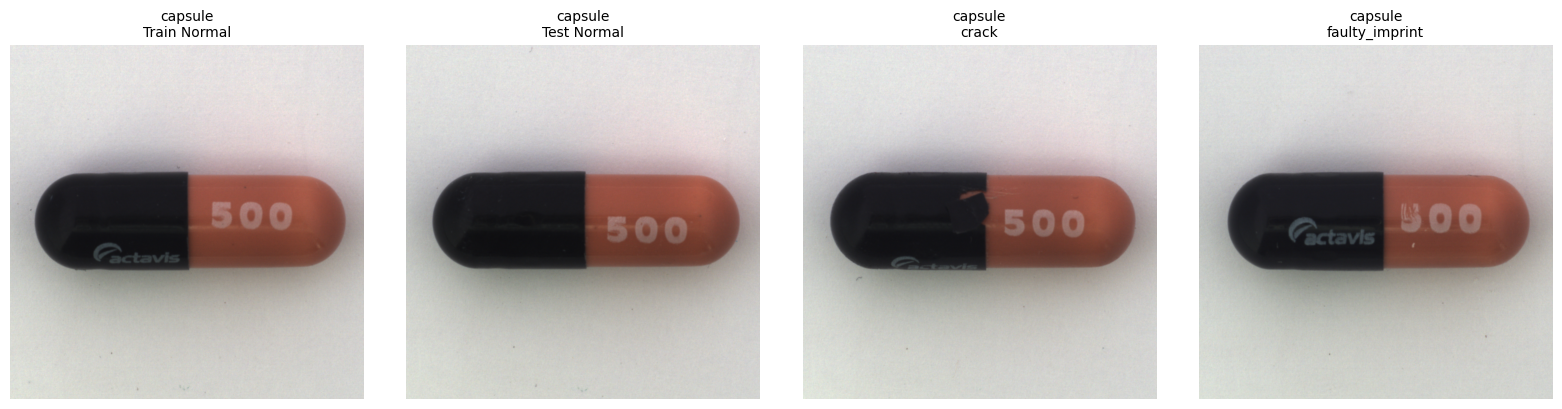


Kích thước ảnh:
capsule         | 1000x1000 | Tỉ lệ: 1.00 | Mode: RGB | Sample: 015.png

Phân bố defect types:


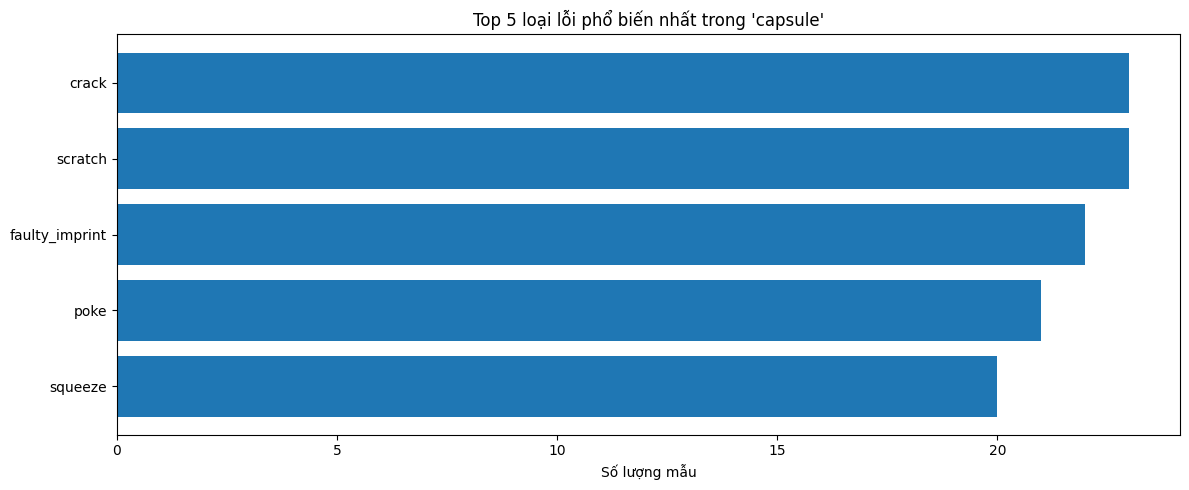


Hoàn thành lúc: 2026-05-11 11:08:18


In [12]:
# --- [CELL 11]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 12}
stats, dim, dist = explore_one_category(DATA_DIR, "capsule")

Đang trực quan hóa mẫu từ các danh mục đã chọn...


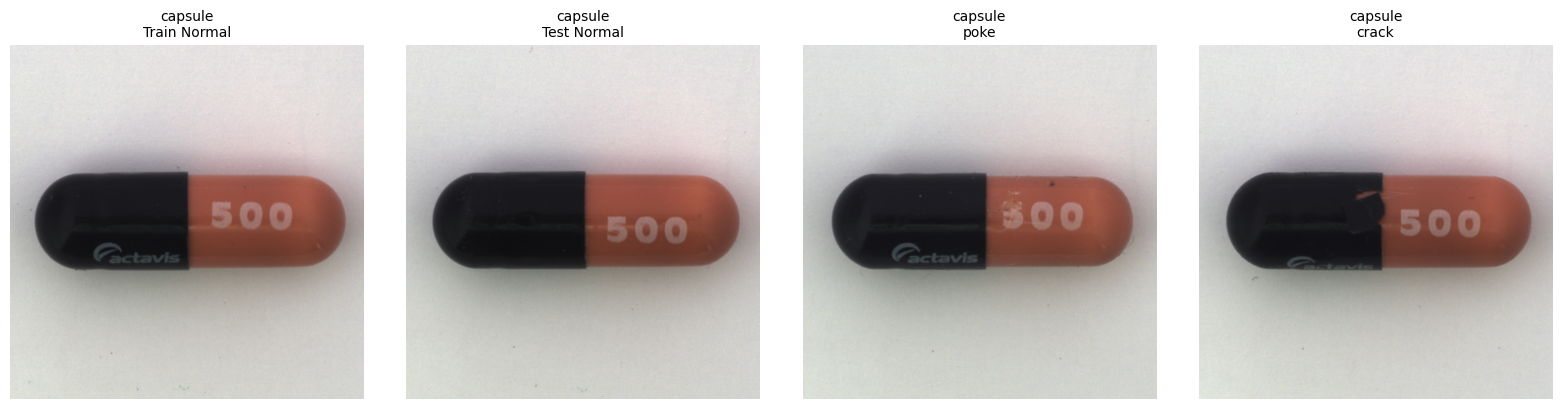


Phân tích kích thước ảnh:
--------------------------------------------------------------------------------
capsule         | 1000x1000 | Tỉ lệ: 1.00 | Định dạng: RGB

Phân bố loại lỗi:
--------------------------------------------------------------------------------
Tổng số loại lỗi (duy nhất): 5

crack                | Số lượng:   23
scratch              | Số lượng:   23
faulty_imprint       | Số lượng:   22
poke                 | Số lượng:   21
squeeze              | Số lượng:   20


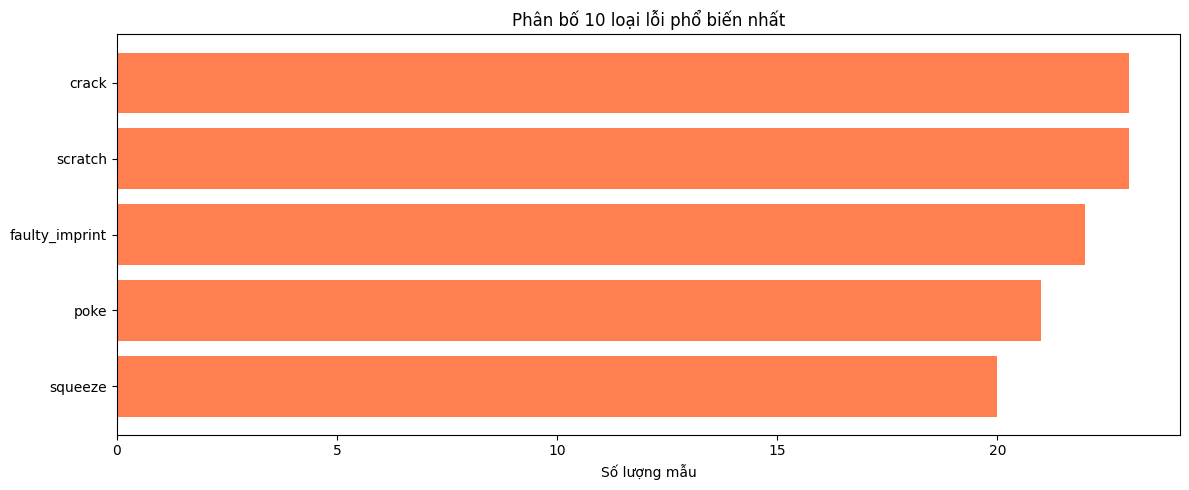


Khám phá dữ liệu hoàn tất!
Hoàn thành lúc: 2026-05-11 11:08:19


In [13]:
# --- [CELL 12]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 13}
# Cell 3: Khám phá dữ liệu và trực quan hóa

from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Hàm nạp ảnh mẫu từ một danh mục
def load_samples(category, data_dir, n_samples=3):
    """Nạp mẫu bình thường và bất thường từ một danh mục"""
    samples = {'normal_train': [], 'normal_test': [], 'anomaly': {}}
    
    category_path = data_dir / category
    
    # Nạp mẫu bình thường trong tập train
    train_normal_path = category_path / 'train' / 'good'
    if train_normal_path.exists():
        train_images = list(train_normal_path.glob('*.png'))[:n_samples]
        samples['normal_train'] = [Image.open(img) for img in train_images]
    
    # Nạp mẫu bình thường trong tập test
    test_normal_path = category_path / 'test' / 'good'
    if test_normal_path.exists():
        test_images = list(test_normal_path.glob('*.png'))[:n_samples]
        samples['normal_test'] = [Image.open(img) for img in test_images]
    
    # Nạp mẫu bất thường theo từng loại lỗi
    test_path = category_path / 'test'
    if test_path.exists():
        anomaly_types = [d.name for d in test_path.iterdir() if d.is_dir() and d.name != 'good']
        for anom_type in anomaly_types[:3]:  # Giới hạn tối đa 3 loại bất thường
            anom_images = list((test_path / anom_type).glob('*.png'))[:n_samples]
            samples['anomaly'][anom_type] = [Image.open(img) for img in anom_images[:1]]  # 1 ảnh mỗi loại
    
    return samples

# Trực quan hóa mẫu từ nhiều danh mục
print("Đang trực quan hóa mẫu từ các danh mục đã chọn...")
selected_categories = categories[:3]  # Hiển thị 3 danh mục đầu tiên

fig, axes = plt.subplots(len(selected_categories), 4, figsize=(16, 4 * len(selected_categories)))
if len(selected_categories) == 1:
    axes = axes.reshape(1, -1)

for idx, category in enumerate(selected_categories):
    samples = load_samples(category, DATA_DIR, n_samples=1)
    
    # Cột 0: Bình thường (train)
    if samples['normal_train']:
        axes[idx, 0].imshow(samples['normal_train'][0])
        axes[idx, 0].set_title(f"{category}\nTrain Normal", fontsize=10)
    axes[idx, 0].axis('off')
    
    # Cột 1: Bình thường (test)
    if samples['normal_test']:
        axes[idx, 1].imshow(samples['normal_test'][0])
        axes[idx, 1].set_title(f"{category}\nTest Normal", fontsize=10)
    axes[idx, 1].axis('off')
    
    # Cột 2-3: Bất thường
    anom_col = 2
    for anom_type, images in list(samples['anomaly'].items())[:2]:
        if images:
            axes[idx, anom_col].imshow(images[0])
            axes[idx, anom_col].set_title(f"{category}\n{anom_type}", fontsize=10)
        axes[idx, anom_col].axis('off')
        anom_col += 1
    
    # Điền các cột còn lại nếu ít hơn 2 loại bất thường
    while anom_col < 4:
        axes[idx, anom_col].axis('off')
        anom_col += 1

plt.tight_layout()
plt.show()

# Phân tích kích thước ảnh theo danh mục
print("\nPhân tích kích thước ảnh:")
print("-" * 80)
dimension_stats = []

for category in categories:
    category_path = DATA_DIR / category / 'train' / 'good'
    if category_path.exists():
        sample_img = Image.open(list(category_path.glob('*.png'))[0])
        width, height = sample_img.size
        dimension_stats.append({
            'Category': category,
            'Width': width,
            'Height': height,
            'Aspect Ratio': f"{width/height:.2f}",
            'Format': sample_img.mode
        })
        print(f"{category:15s} | {width}x{height} | Tỉ lệ: {width/height:.2f} | Định dạng: {sample_img.mode}")

# Phân bố loại lỗi trên toàn bộ danh mục
print("\nPhân bố loại lỗi:")
print("-" * 80)
all_defect_types = {}

for category in categories:
    test_path = DATA_DIR / category / 'test'
    if test_path.exists():
        anomaly_types = [d.name for d in test_path.iterdir() if d.is_dir() and d.name != 'good']
        for anom_type in anomaly_types:
            count = len(list((test_path / anom_type).glob('*.png')))
            if anom_type not in all_defect_types:
                all_defect_types[anom_type] = 0
            all_defect_types[anom_type] += count

# Sắp xếp loại lỗi theo tần suất
sorted_defects = sorted(all_defect_types.items(), key=lambda x: x[1], reverse=True)
print(f"Tổng số loại lỗi (duy nhất): {len(sorted_defects)}\n")
for defect, count in sorted_defects[:10]:  # Hiển thị 10 loại phổ biến nhất
    print(f"{defect:20s} | Số lượng: {count:4d}")

# Trực quan hóa phân bố lỗi
if len(sorted_defects) > 0:
    defect_names = [d[0] for d in sorted_defects[:10]]
    defect_counts = [d[1] for d in sorted_defects[:10]]
    
    plt.figure(figsize=(12, 5))
    plt.barh(defect_names, defect_counts, color='coral')
    plt.xlabel('Số lượng mẫu')
    plt.title('Phân bố 10 loại lỗi phổ biến nhất')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

print("\nKhám phá dữ liệu hoàn tất!")
print(f"Hoàn thành lúc: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

In [14]:
# --- [CELL 13]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 14}
# Cấu hình và siêu tham số

import os
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, field
from typing import List, Tuple, Optional
import torch

@dataclass
class Config:
    # ===== ĐƯỜNG DẪN =====
    data_dir: Path = field(default_factory=lambda: Path('data'))
    output_dir: Path = field(default_factory=lambda: Path('outputs'))
    model_dir: Path = field(default_factory=lambda: Path('models'))
    results_dir: Path = field(default_factory=lambda: Path('results'))

    # ===== CHỈ CHẠY 1 DANH MỤC =====
    target_category: str = "capsule"   # <-- đổi category bạn muốn
    categories: List[str] = field(default_factory=list)  # sẽ auto set = [target_category]

    # ===== THAM SỐ MÔ HÌNH (PatchCore/DINOv2) =====
    model_name: str = 'dinov2_vitb14'
    feature_dim: int = 768
    patch_size: int = 14

    # ===== FEW-SHOT =====
    k_shot: int = 4
    use_few_shot: bool = True

    # ===== TIỀN XỬ LÝ ẢNH =====
    img_size: Tuple[int, int] = (224, 224)
    normalize_mean: Tuple[float, float, float] = (0.485, 0.456, 0.406)
    normalize_std: Tuple[float, float, float] = (0.229, 0.224, 0.225)

    # ===== THAM SỐ CHẠY =====
    batch_size: int = 32
    num_workers: int = 0

    # ===== MEMORY BANK =====
    memory_bank_size: Optional[int] = None
    distance_metric: str = 'euclidean'

    # ===== PHÁT HIỆN BẤT THƯỜNG =====
    anomaly_threshold: Optional[float] = None
    top_k_neighbors: int = 5

    # ===== THIẾT BỊ =====
    device: str = field(default_factory=lambda: 'cuda' if torch.cuda.is_available() else 'cpu')

    # ===== TÁI LẬP =====
    seed: int = 42

    # ===== LOG =====
    verbose: bool = True
    save_predictions: bool = True
    save_visualizations: bool = True

    def __post_init__(self):
        # tạo thư mục
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.model_dir.mkdir(parents=True, exist_ok=True)
        self.results_dir.mkdir(parents=True, exist_ok=True)

        # validate dataset + category
        if not self.data_dir.exists():
            raise FileNotFoundError(f"Dataset không tìm thấy tại {self.data_dir}")

        all_cats = sorted([d for d in os.listdir(self.data_dir) if os.path.isdir(self.data_dir / d)])
        if self.target_category not in all_cats:
            raise ValueError(f"target_category='{self.target_category}' không tồn tại. Available: {all_cats}")

        # ép categories chỉ gồm 1 category mục tiêu
        self.categories = [self.target_category]

    def display(self):
        print("=" * 80)
        print("CÁC THIẾT LẬP CẤU HÌNH (SINGLE-CATEGORY)")
        print("=" * 80)
        print(f"Data dir:        {self.data_dir}")
        print(f"Output dir:      {self.output_dir}")
        print(f"Model dir:       {self.model_dir}")
        print(f"Results dir:     {self.results_dir}")
        print(f"\nTarget category: {self.target_category}")
        print(f"Categories used: {self.categories}")
        print(f"\nModel: {self.model_name} | feat_dim={self.feature_dim} | patch={self.patch_size}")
        print(f"Img size: {self.img_size} | metric={self.distance_metric} | topk={self.top_k_neighbors}")
        print(f"Device: {self.device}" + (f" | GPU: {torch.cuda.get_device_name(0)}" if self.device=="cuda" else ""))
        print("=" * 80)

In [15]:
# --- [CELL 14]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 15}
capsule_config = Config(target_category="capsule") 
capsule_config.display()

CÁC THIẾT LẬP CẤU HÌNH (SINGLE-CATEGORY)
Data dir:        data
Output dir:      outputs
Model dir:       models
Results dir:     results

Target category: capsule
Categories used: ['capsule']

Model: dinov2_vitb14 | feat_dim=768 | patch=14
Img size: (224, 224) | metric=euclidean | topk=5
Device: cpu


In [16]:
# --- [CELL 15]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 16}
class ImageTransforms:
    @staticmethod
    def get_train_transforms(img_size, mean, std):
        return T.Compose([
            T.Resize(img_size),
            T.ToTensor(),
            T.Normalize(mean=mean, std=std),
        ])

    @staticmethod
    def get_test_transforms(img_size, mean, std):
        return T.Compose([
            T.Resize(img_size),
            T.ToTensor(),
            T.Normalize(mean=mean, std=std),
        ])

# -----------------------
# Dataset
# -----------------------
class MVTecDataset(Dataset):
    """Dataset MVTec AD (1 category) cho anomaly detection"""
    def __init__(self, root_dir, category, split='train', transform=None):
        self.root_dir = Path(root_dir)
        self.category = category
        self.split = split
        self.transform = transform

        self.image_paths = []
        self.labels = []       # 0=good, 1=anomaly
        self.defect_types = [] # 'good' hoặc tên defect folder

        self._load_data()

    def _load_data(self):
        category_path = self.root_dir / self.category / self.split

        if self.split == 'train':
            good_dir = category_path / 'good'
            if good_dir.exists():
                for img_path in sorted(good_dir.glob('*.png')):
                    self.image_paths.append(img_path)
                    self.labels.append(0)
                    self.defect_types.append('good')
        else:
            # test: good + defects
            if category_path.exists():
                for defect_dir in sorted([d for d in category_path.iterdir() if d.is_dir()]):
                    label = 0 if defect_dir.name == 'good' else 1
                    for img_path in sorted(defect_dir.glob('*.png')):
                        self.image_paths.append(img_path)
                        self.labels.append(label)
                        self.defect_types.append(defect_dir.name)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        defect_type = self.defect_types[idx]

        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'label': label,
            'defect_type': defect_type,
            'path': str(img_path)
        }

# -----------------------
# Few-shot loader
# -----------------------
def create_few_shot_loader(dataset, k_shot, batch_size, shuffle=False, num_workers=2, device="cpu", seed=42):
    """Tạo DataLoader với cơ chế lấy mẫu k-shot (chỉ áp dụng cho train)."""
    if k_shot is not None and k_shot < len(dataset):
        rng = random.Random(seed)
        indices = rng.sample(range(len(dataset)), k_shot)
        dataset = Subset(dataset, indices)
        print(f"  Few-shot enabled: dùng {k_shot} mẫu train/good")

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=True if device == 'cuda' else False
    )
    return loader

# -----------------------
# Main function: build loaders for ONE category
# -----------------------
def build_loaders_for_one_category(config, category=None, visualize_batch=True):
    """Tạo train/test dataset + loader cho đúng 1 category."""
    category = category or config.target_category
    assert category is not None, "Hãy set config.target_category = 'capsule' (hoặc truyền category vào hàm)."

    print("Đang khởi tạo biến đổi ảnh...")
    train_transform = ImageTransforms.get_train_transforms(config.img_size, config.normalize_mean, config.normalize_std)
    test_transform  = ImageTransforms.get_test_transforms(config.img_size, config.normalize_mean, config.normalize_std)
    print("Đã tạo transform cho train/test")

    print(f"\nĐang tạo dataset cho category: {category}")
    train_dataset = MVTecDataset(config.data_dir, category, split='train', transform=train_transform)
    test_dataset  = MVTecDataset(config.data_dir, category, split='test',  transform=test_transform)

    print(f"  Số mẫu train: {len(train_dataset)}")
    print(f"  Số mẫu test:  {len(test_dataset)}")

    test_normal = sum(1 for y in test_dataset.labels if y == 0)
    test_anom   = sum(1 for y in test_dataset.labels if y == 1)
    print(f"  Test bình thường: {test_normal}")
    print(f"  Test bất thường:  {test_anom}")

    print("\nĐang tạo DataLoader...")
    train_loader = create_few_shot_loader(
        dataset=train_dataset,
        k_shot=config.k_shot if config.use_few_shot else None,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        device=config.device,
        seed=config.seed,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=True if config.device == 'cuda' else False
    )

    print(f"Đã tạo train loader: {len(train_loader)} batches")
    print(f"Đã tạo test loader:  {len(test_loader)} batches")

    # Visualize 1 batch train (denorm)
    if visualize_batch:
        print("\nĐang kiểm thử nạp batch...")
        sample_batch = next(iter(train_loader))
        print(f"  Batch image shape: {sample_batch['image'].shape}")
        print(f"  Labels: {sample_batch['label'].tolist()}")
        print(f"  defect_type (first 5): {sample_batch['defect_type'][:5]}")

        n_show = min(4, len(sample_batch['image']))
        fig, axes = plt.subplots(1, n_show, figsize=(3*n_show, 3))
        if n_show == 1:
            axes = [axes]

        mean = np.array(config.normalize_mean, dtype=np.float32)
        std  = np.array(config.normalize_std, dtype=np.float32)

        for i in range(n_show):
            img = sample_batch['image'][i].permute(1, 2, 0).numpy()
            img = img * std + mean
            img = np.clip(img, 0, 1)

            axes[i].imshow(img)
            axes[i].set_title(f"label={int(sample_batch['label'][i])}")
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

    print(f"\nTiền xử lý dữ liệu và DataLoader đã sẵn sàng! ({datetime.now().strftime('%Y-%m-%d %H:%M:%S')})")
    return train_dataset, test_dataset, train_loader, test_loader

Đang khởi tạo biến đổi ảnh...
Đã tạo transform cho train/test

Đang tạo dataset cho category: capsule
  Số mẫu train: 219
  Số mẫu test:  132
  Test bình thường: 23
  Test bất thường:  109

Đang tạo DataLoader...
  Few-shot enabled: dùng 4 mẫu train/good
Đã tạo train loader: 1 batches
Đã tạo test loader:  5 batches

Đang kiểm thử nạp batch...
  Batch image shape: torch.Size([4, 3, 224, 224])
  Labels: [0, 0, 0, 0]
  defect_type (first 5): ['good', 'good', 'good', 'good']


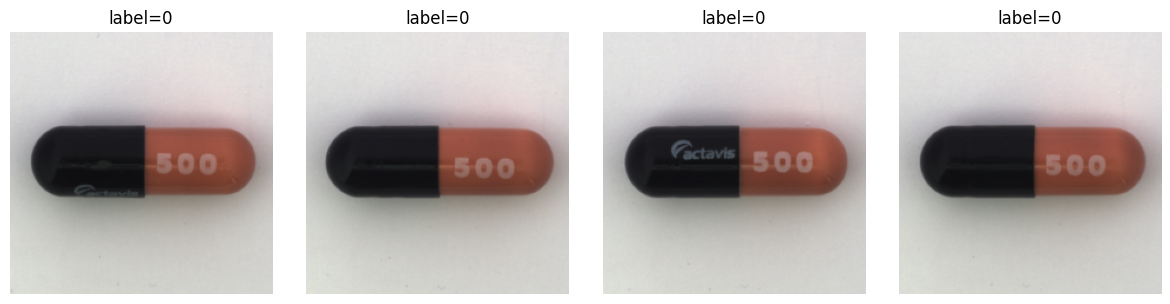


Tiền xử lý dữ liệu và DataLoader đã sẵn sàng! (2026-05-11 11:08:20)


In [17]:
# --- [CELL 16]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 17}
capsule_train_ds, capsule_test_ds, capsule_train_loader, capsule_test_loader = build_loaders_for_one_category(capsule_config)

In [18]:
# --- [CELL 17]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 18}
# Bộ trích xuất đặc trưng - DINOv2

from datetime import datetime
import torch.nn.functional as F

class DINOv2FeatureExtractor(nn.Module):
    """Vision Transformer DINOv2 dùng để trích xuất đặc trưng"""
    
    def __init__(self, model_name='dinov2_vitb14', device='cuda'):
        """
        Khởi tạo bộ trích xuất đặc trưng DINOv2
        Args:
            model_name: Biến thể mô hình ('dinov2_vitb14', 'dinov2_vits14', 'dinov2_vitl14')
            device: Thiết bị để nạp mô hình
        """
        super().__init__()
        self.model_name = model_name
        self.device = device
        
        # Nạp mô hình DINOv2 đã tiền huấn luyện từ torch hub
        print(f"Đang nạp {model_name} từ torch hub...")
        self.model = torch.hub.load('facebookresearch/dinov2', model_name)
        
        # Chuyển lên thiết bị
        self.model = self.model.to(device)
        
        # Đóng băng toàn bộ tham số (không huấn luyện)
        self.freeze_backbone()
        
        # Chuyển sang chế độ đánh giá
        self.model.eval()
        
        # Lấy thông tin mô hình
        self.feature_dim = self.model.embed_dim
        self.patch_size = self.model.patch_size
        
        print(f"Đã nạp mô hình: {model_name}")
        print(f"  Kích thước đặc trưng: {self.feature_dim}")
        print(f"  Kích thước patch: {self.patch_size}")
    
    def freeze_backbone(self):
        """Đóng băng toàn bộ tham số của backbone"""
        for param in self.model.parameters():
            param.requires_grad = False
        print("Đã đóng băng trọng số backbone")
    
    def forward(self, x):
        """
        Trích xuất đặc trưng theo patch từ ảnh đầu vào
        Args:
            x: Tensor đầu vào [B, C, H, W]
        Returns:
            patch_features: Đặc trưng theo patch [B, N_patches, feature_dim]
        """
        with torch.no_grad():
            # Lấy embedding từ DINOv2
            # DINOv2 trả về [CLS token, patch tokens]
            features = self.model.forward_features(x)
            
            # Chỉ lấy patch tokens (loại CLS token)
            patch_features = features['x_norm_patchtokens']
            
            return patch_features
    
    def extract_features(self, dataloader, max_samples=None):
        """
        Trích xuất đặc trưng cho toàn bộ dataset
        Args:
            dataloader: PyTorch DataLoader
            max_samples: Số mẫu tối đa cần xử lý (None = tất cả)
        Returns:
            all_features: Tensor đặc trưng đã ghép
            all_labels: Tensor nhãn đã ghép
        """
        all_features = []
        all_labels = []
        
        self.model.eval()
        with torch.no_grad():
            for batch_idx, batch in enumerate(dataloader):
                if max_samples and batch_idx * dataloader.batch_size >= max_samples:
                    break
                
                images = batch['image'].to(self.device)
                labels = batch['label']
                
                # Trích xuất đặc trưng
                features = self.forward(images)
                
                all_features.append(features.cpu())
                all_labels.append(labels)
        
        # Ghép tất cả batch
        all_features = torch.cat(all_features, dim=0)
        all_labels = torch.cat(all_labels, dim=0)
        
        return all_features, all_labels
    
    def get_num_patches(self, img_size):
        """Tính số lượng patch ứng với kích thước ảnh đã cho"""
        h, w = img_size
        num_patches_h = h // self.patch_size
        num_patches_w = w // self.patch_size
        return num_patches_h * num_patches_w

Đang nạp dinov2_vitb14 từ torch hub...


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /tmp/xdg-cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /tmp/xdg-cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth
100%|██████████| 330M/330M [00:03<00:00, 96.1MB/s]


Đã đóng băng trọng số backbone
Đã nạp mô hình: dinov2_vitb14
  Kích thước đặc trưng: 768
  Kích thước patch: 14
Đang khởi tạo bộ trích xuất đặc trưng DINOv2...

Tính toán patch:
  Kích thước đầu vào: (224, 224)
  Kích thước patch: 14x14
  Số lượng patch: 256
  Dạng đặc trưng mỗi ảnh: [256, 768]

Đang kiểm thử trích xuất đặc trưng trên batch mẫu...
  Dạng đầu vào: torch.Size([4, 3, 224, 224])
  Dạng đầu ra: torch.Size([4, 256, 768])
  Kiểu dữ liệu đặc trưng: torch.float32
  Miền giá trị đặc trưng: [-15.931, 25.337]

Thống kê đặc trưng:
  Trung bình: -0.0290
  Độ lệch chuẩn: 1.7159
  Chuẩn L2 (trung bình): 47.4934

Bộ nhớ cho mỗi ảnh: 0.75 MB
  Tổng đặc trưng train: 164.25 MB


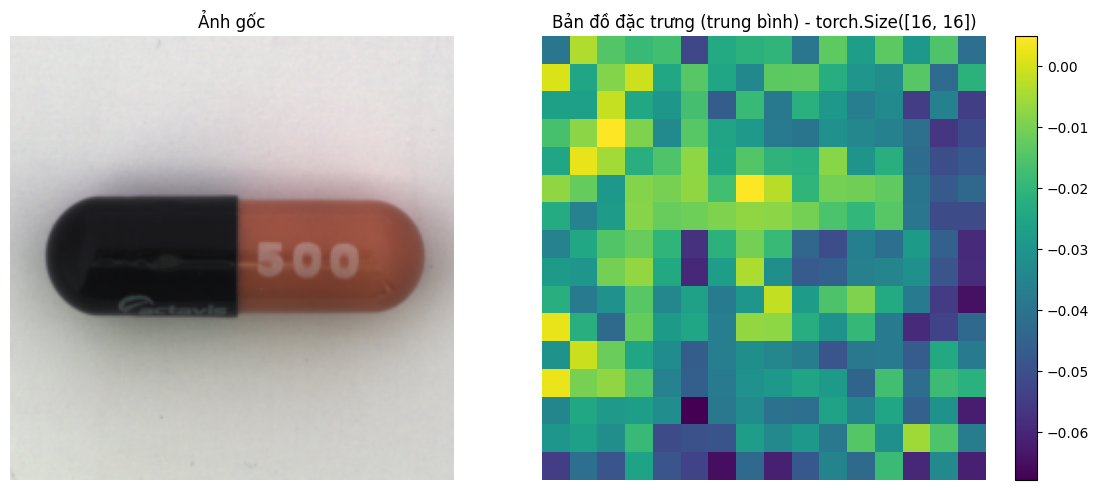


Bộ trích xuất đặc trưng DINOv2 đã sẵn sàng!
Hoàn thành lúc: 2026-05-11 11:08:30


In [19]:
# --- [CELL 18]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 19}
# Khởi tạo bộ trích xuất đặc trưng DINOv2...
capsule_feature_extractor = DINOv2FeatureExtractor(
    model_name=capsule_config.model_name,
    device=capsule_config.device
)
# Khởi tạo bộ trích xuất đặc trưng DINOv2
print("Đang khởi tạo bộ trích xuất đặc trưng DINOv2...")


# Tính số lượng patch kỳ vọng
num_patches = capsule_feature_extractor.get_num_patches(capsule_config.img_size)
print(f"\nTính toán patch:")
print(f"  Kích thước đầu vào: {capsule_config.img_size}")
print(f"  Kích thước patch: {capsule_feature_extractor.patch_size}x{capsule_feature_extractor.patch_size}")
print(f"  Số lượng patch: {num_patches}")
print(f"  Dạng đặc trưng mỗi ảnh: [{num_patches}, {capsule_feature_extractor.feature_dim}]")

# Kiểm thử trích xuất đặc trưng trên batch mẫu
print(f"\nĐang kiểm thử trích xuất đặc trưng trên batch mẫu...")
capsule_sample_batch = next(iter(capsule_train_loader))
capsule_sample_images = capsule_sample_batch['image'].to(capsule_config.device)

print(f"  Dạng đầu vào: {capsule_sample_images.shape}")

# Trích xuất đặc trưng
with torch.no_grad():
    sample_features = capsule_feature_extractor(capsule_sample_images)

print(f"  Dạng đầu ra: {sample_features.shape}")
print(f"  Kiểu dữ liệu đặc trưng: {sample_features.dtype}")
print(f"  Miền giá trị đặc trưng: [{sample_features.min():.3f}, {sample_features.max():.3f}]")

# Thống kê đặc trưng
print(f"\nThống kê đặc trưng:")
print(f"  Trung bình: {sample_features.mean():.4f}")
print(f"  Độ lệch chuẩn: {sample_features.std():.4f}")
print(f"  Chuẩn L2 (trung bình): {torch.norm(sample_features, dim=-1).mean():.4f}")

# Ước lượng bộ nhớ sử dụng
feature_memory_mb = (num_patches * capsule_feature_extractor.feature_dim * 4) / (1024**2)  # 4 byte cho float32
print(f"\nBộ nhớ cho mỗi ảnh: {feature_memory_mb:.2f} MB")
print(f"  Tổng đặc trưng train: {len(capsule_train_ds) * feature_memory_mb:.2f} MB")

# Hiển thị ảnh đầu tiên và bản đồ đặc trưng tương ứng
sample_img = capsule_sample_images[0].cpu()
sample_feat = sample_features[0].cpu()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Ảnh gốc (khử chuẩn hóa)
img_display = sample_img.permute(1, 2, 0).numpy()
img_display = img_display * np.array(capsule_config.normalize_std) + np.array(capsule_config.normalize_mean)
img_display = np.clip(img_display, 0, 1)
axes[0].imshow(img_display)
axes[0].set_title("Ảnh gốc")
axes[0].axis('off')

# Bản đồ đặc trưng (lấy trung bình theo chiều đặc trưng)
feat_map = sample_feat.mean(dim=-1).reshape(
    capsule_config.img_size[0] // capsule_feature_extractor.patch_size,
    capsule_config.img_size[1] // capsule_feature_extractor.patch_size
)
im = axes[1].imshow(feat_map, cmap='viridis')
axes[1].set_title(f"Bản đồ đặc trưng (trung bình) - {feat_map.shape}")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"\nBộ trích xuất đặc trưng DINOv2 đã sẵn sàng!")
print(f"Hoàn thành lúc: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

In [20]:
# --- [CELL 19]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 20}
# 7: Xây dựng Memory Bank

from datetime import datetime
from sklearn.random_projection import SparseRandomProjection

class MemoryBank:
    """Memory bank dùng để lưu đặc trưng của các mẫu bình thường"""
    
    def __init__(self, feature_dim, coreset_sampling_ratio=0.1):
        """
        Khởi tạo memory bank
        Args:
            feature_dim: Số chiều của vector đặc trưng
            coreset_sampling_ratio: Tỉ lệ đặc trưng giữ lại (0.1 = 10%)
        """
        self.feature_dim = feature_dim
        self.coreset_sampling_ratio = coreset_sampling_ratio
        self.memory_bank = None
        self.coreset_indices = None
        
    def build(self, features):
        """
        Xây dựng memory bank từ đặc trưng train
        Args:
            features: Đặc trưng train [N_samples, N_patches, feature_dim]
        """
        print(f"Đang xây dựng memory bank...")
        print(f"  Dạng đầu vào: {features.shape}")
        
        # Dàn phẳng về [N_samples * N_patches, feature_dim]
        N_samples, N_patches, feat_dim = features.shape
        features_flat = features.reshape(-1, feat_dim)
        print(f"  Dạng sau khi dàn phẳng: {features_flat.shape}")
        
        # Áp dụng coreset subsampling để giảm bộ nhớ
        if self.coreset_sampling_ratio < 1.0:
            n_coreset = int(features_flat.shape[0] * self.coreset_sampling_ratio)
            print(f"  Áp dụng coreset subsampling: {features_flat.shape[0]} → {n_coreset}")
            
            # Lấy mẫu ngẫu nhiên cho coreset
            self.coreset_indices = np.random.choice(
                features_flat.shape[0],
                size=n_coreset,
                replace=False
            )
            self.memory_bank = features_flat[self.coreset_indices].numpy()
        else:
            # Dùng toàn bộ đặc trưng
            self.memory_bank = features_flat.numpy()
            self.coreset_indices = np.arange(features_flat.shape[0])
        
        print(f"  Kích thước memory bank: {self.memory_bank.shape}")
        print(f"  Dung lượng bộ nhớ: {self.memory_bank.nbytes / (1024**2):.2f} MB")
        
        return self.memory_bank
    
    def get_memory_bank(self):
        """Lấy mảng memory bank"""
        return self.memory_bank
    
    def compute_distances(self, query_features, metric='euclidean'):
        """
        Tính khoảng cách giữa đặc trưng truy vấn và memory bank
        Args:
            query_features: Đặc trưng truy vấn [N_query, feature_dim]
            metric: Thước đo khoảng cách ('euclidean' hoặc 'cosine')
        Returns:
            distances: Ma trận khoảng cách [N_query, N_memory]
        """
        if metric == 'euclidean':
            # Khoảng cách Euclid: ||a - b||_2
            distances = torch.cdist(
                torch.from_numpy(query_features).float(),
                torch.from_numpy(self.memory_bank).float(),
                p=2
            )
        elif metric == 'cosine':
            # Khoảng cách cosine: 1 - cosine_similarity
            query_norm = F.normalize(torch.from_numpy(query_features).float(), dim=-1)
            memory_norm = F.normalize(torch.from_numpy(self.memory_bank).float(), dim=-1)
            distances = 1 - torch.mm(query_norm, memory_norm.t())
        else:
            raise ValueError(f"Không hỗ trợ metric: {metric}")
        
        return distances.numpy()
    
    def get_knn_score(self, query_features, k=5, metric='euclidean'):
        """
        Tính điểm bất thường dựa trên k láng giềng gần nhất
        Args:
            query_features: Đặc trưng truy vấn [N_patches, feature_dim]
            k: Số láng giềng gần nhất
            metric: Thước đo khoảng cách
        Returns:
            anomaly_score: Trung bình khoảng cách tới k-NN
        """
        # Tính khoảng cách tới memory bank
        distances = self.compute_distances(query_features, metric=metric)
        
        # Lấy k khoảng cách nhỏ nhất cho mỗi truy vấn
        k_nearest_distances = np.partition(distances, k-1, axis=1)[:, :k]
        
        # Điểm bất thường: trung bình khoảng cách k-NN
        anomaly_score = k_nearest_distances.mean(axis=1)
        
        return anomaly_score


Đang trích xuất đặc trưng từ tập train...
  Kích thước đặc trưng trích xuất: torch.Size([4, 256, 768])
  Kiểu dữ liệu đặc trưng: torch.float32
  Dung lượng: 3.00 MB
Đang xây dựng memory bank...
  Dạng đầu vào: torch.Size([4, 256, 768])
  Dạng sau khi dàn phẳng: torch.Size([1024, 768])
  Áp dụng coreset subsampling: 1024 → 102
  Kích thước memory bank: (102, 768)
  Dung lượng bộ nhớ: 0.30 MB

Thống kê Memory Bank:
  Tổng số đặc trưng: 102
  Số chiều đặc trưng: 768
  Dung lượng bộ nhớ: 0.30 MB
  Trung bình đặc trưng: -0.0282
  Độ lệch chuẩn đặc trưng: 1.7200

Đang trực quan phân bố đặc trưng trong memory bank...


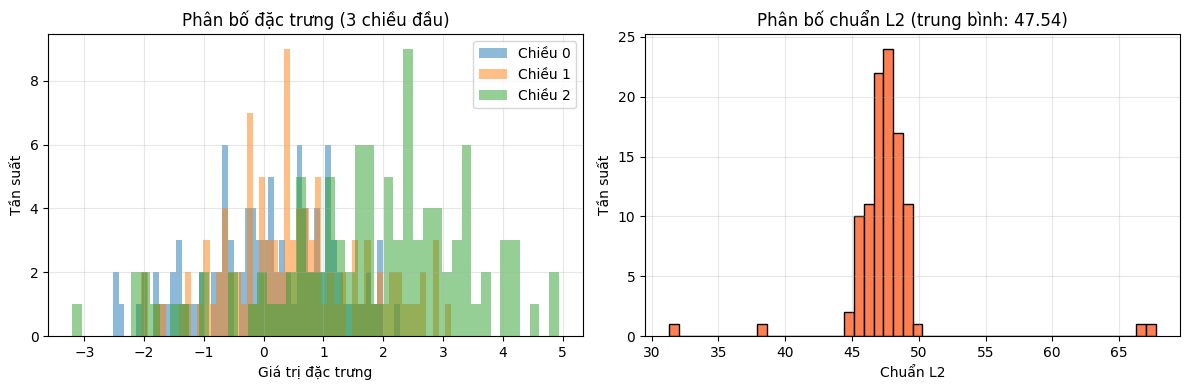


Đang kiểm thử chấm điểm k-NN trên mẫu...
  Dạng truy vấn: (256, 768)
  Dạng điểm k-NN: (256,)
  Miền điểm: [17.0904, 44.2674]
  Điểm trung bình: 29.6650


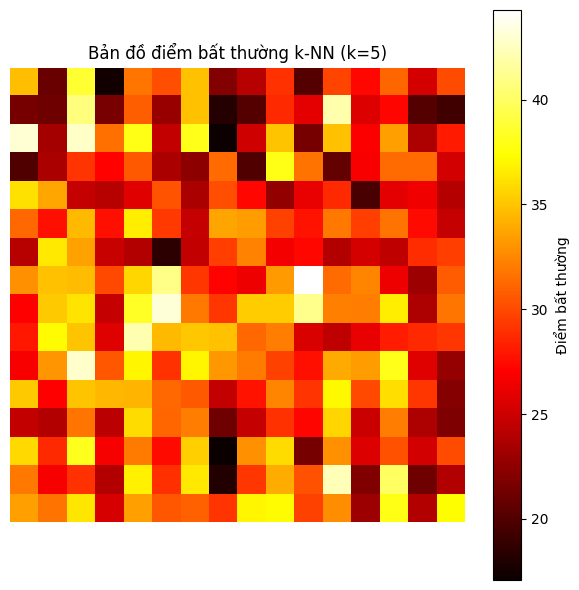


Xây dựng memory bank thành công!
Hoàn thành lúc: 2026-05-11 11:08:33


In [21]:
# --- [CELL 20]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 21}
# Trích xuất đặc trưng từ tập train
print(f"\nĐang trích xuất đặc trưng từ tập train...")
capsule_train_features, capsule_train_labels = capsule_feature_extractor.extract_features(capsule_train_loader)

print(f"  Kích thước đặc trưng trích xuất: {capsule_train_features.shape}")
print(f"  Kiểu dữ liệu đặc trưng: {capsule_train_features.dtype}")
print(f"  Dung lượng: {capsule_train_features.element_size() * capsule_train_features.nelement() / (1024**2):.2f} MB")

# Khởi tạo và xây dựng memory bank
capsule_memory_bank = MemoryBank(
    feature_dim=capsule_config.feature_dim,
    coreset_sampling_ratio=0.1  # Giữ lại 10% patch
)

capsule_memory_bank_array = capsule_memory_bank.build(capsule_train_features)

# Thống kê memory bank
print(f"\nThống kê Memory Bank:")
print(f"  Tổng số đặc trưng: {capsule_memory_bank_array.shape[0]}")
print(f"  Số chiều đặc trưng: {capsule_memory_bank_array.shape[1]}")
print(f"  Dung lượng bộ nhớ: {capsule_memory_bank_array.nbytes / (1024**2):.2f} MB")
print(f"  Trung bình đặc trưng: {capsule_memory_bank_array.mean():.4f}")
print(f"  Độ lệch chuẩn đặc trưng: {capsule_memory_bank_array.std():.4f}")

# Trực quan phân bố đặc trưng
print(f"\nĐang trực quan phân bố đặc trưng trong memory bank...")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Biểu đồ 1: Phân bố của 3 chiều đầu tiên
for i in range(3):
    axes[0].hist(capsule_memory_bank_array[:, i], bins=50, alpha=0.5, label=f'Chiều {i}')
axes[0].set_xlabel('Giá trị đặc trưng')
axes[0].set_ylabel('Tần suất')
axes[0].set_title('Phân bố đặc trưng (3 chiều đầu)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Biểu đồ 2: Phân bố chuẩn L2
l2_norms = np.linalg.norm(capsule_memory_bank_array, axis=1)
axes[1].hist(l2_norms, bins=50, color='coral', edgecolor='black')
axes[1].set_xlabel('Chuẩn L2')
axes[1].set_ylabel('Tần suất')
axes[1].set_title(f'Phân bố chuẩn L2 (trung bình: {l2_norms.mean():.2f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Kiểm thử chấm điểm k-NN trên một mẫu
print(f"\nĐang kiểm thử chấm điểm k-NN trên mẫu...")
sample_query = capsule_train_features[0].numpy()  # Ảnh train đầu tiên
print(f"  Dạng truy vấn: {sample_query.shape}")

knn_scores = capsule_memory_bank.get_knn_score(
    sample_query,
    k=capsule_config.top_k_neighbors,
    metric=capsule_config.distance_metric
)

print(f"  Dạng điểm k-NN: {knn_scores.shape}")
print(f"  Miền điểm: [{knn_scores.min():.4f}, {knn_scores.max():.4f}]")
print(f"  Điểm trung bình: {knn_scores.mean():.4f}")

# Trực quan điểm k-NN dưới dạng heatmap
score_map = knn_scores.reshape(
    capsule_config.img_size[0] // capsule_feature_extractor.patch_size,
    capsule_config.img_size[1] // capsule_feature_extractor.patch_size
)

plt.figure(figsize=(6, 6))
plt.imshow(score_map, cmap='hot', interpolation='nearest')
plt.colorbar(label='Điểm bất thường')
plt.title(f'Bản đồ điểm bất thường k-NN (k={capsule_config.top_k_neighbors})')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\nXây dựng memory bank thành công!")
print(f"Hoàn thành lúc: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

In [22]:
# --- [CELL 21]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 22}
# Part 8: Chấm điểm bất thường và định vị vùng bất thường

from scipy.ndimage import gaussian_filter
from sklearn.metrics import roc_auc_score
import cv2

class AnomalyScorer:
    """Tính điểm bất thường và bản đồ định vị"""
    
    def __init__(self, memory_bank, feature_extractor, config):
        self.memory_bank = memory_bank
        self.feature_extractor = feature_extractor
        self.config = config
        
    def compute_anomaly_map(self, features):
        """
        Tính bản đồ bất thường từ đặc trưng theo patch
        Args:
            features: [N_patches, feature_dim]
        Returns:
            anomaly_map: [H_patches, W_patches]
        """
        scores = self.memory_bank.get_knn_score(
            features,
            k=self.config.top_k_neighbors,
            metric=self.config.distance_metric
        )
        
        h_patches = self.config.img_size[0] // self.feature_extractor.patch_size
        w_patches = self.config.img_size[1] // self.feature_extractor.patch_size
        anomaly_map = scores.reshape(h_patches, w_patches)
        
        return anomaly_map
    
    def upsample_anomaly_map(self, anomaly_map):
        """
        Nội suy bản đồ bất thường lên kích thước ảnh đầu vào
        Args:
            anomaly_map: [H_patches, W_patches]
        Returns:
            upsampled_map: [H_img, W_img]
        """
        upsampled = cv2.resize(
            anomaly_map,
            (self.config.img_size[1], self.config.img_size[0]),
            interpolation=cv2.INTER_LINEAR
        )
        upsampled = gaussian_filter(upsampled, sigma=4)
        return upsampled
    
    def score_batch(self, test_features):
        """
        Chấm điểm cho một batch ảnh test
        Args:
            test_features: [N_images, N_patches, feature_dim]
        Returns:
            image_scores: [N_images]
            anomaly_maps: [N_images, H_img, W_img]
        """
        N_images = test_features.shape[0]
        image_scores = []
        anomaly_maps = []
        
        for i in range(N_images):
            patch_map = self.compute_anomaly_map(test_features[i].numpy())
            full_map = self.upsample_anomaly_map(patch_map)
            img_score = full_map.max()
            
            image_scores.append(img_score)
            anomaly_maps.append(full_map)
        
        return np.array(image_scores), np.array(anomaly_maps)

  Kích thước đặc trưng test: torch.Size([132, 256, 768])
  Kích thước điểm theo ảnh: (132,)
  Kích thước bản đồ bất thường: (132, 224, 224)
  Miền điểm: [39.5837, 53.7823]

AUROC mức ảnh: 0.8037


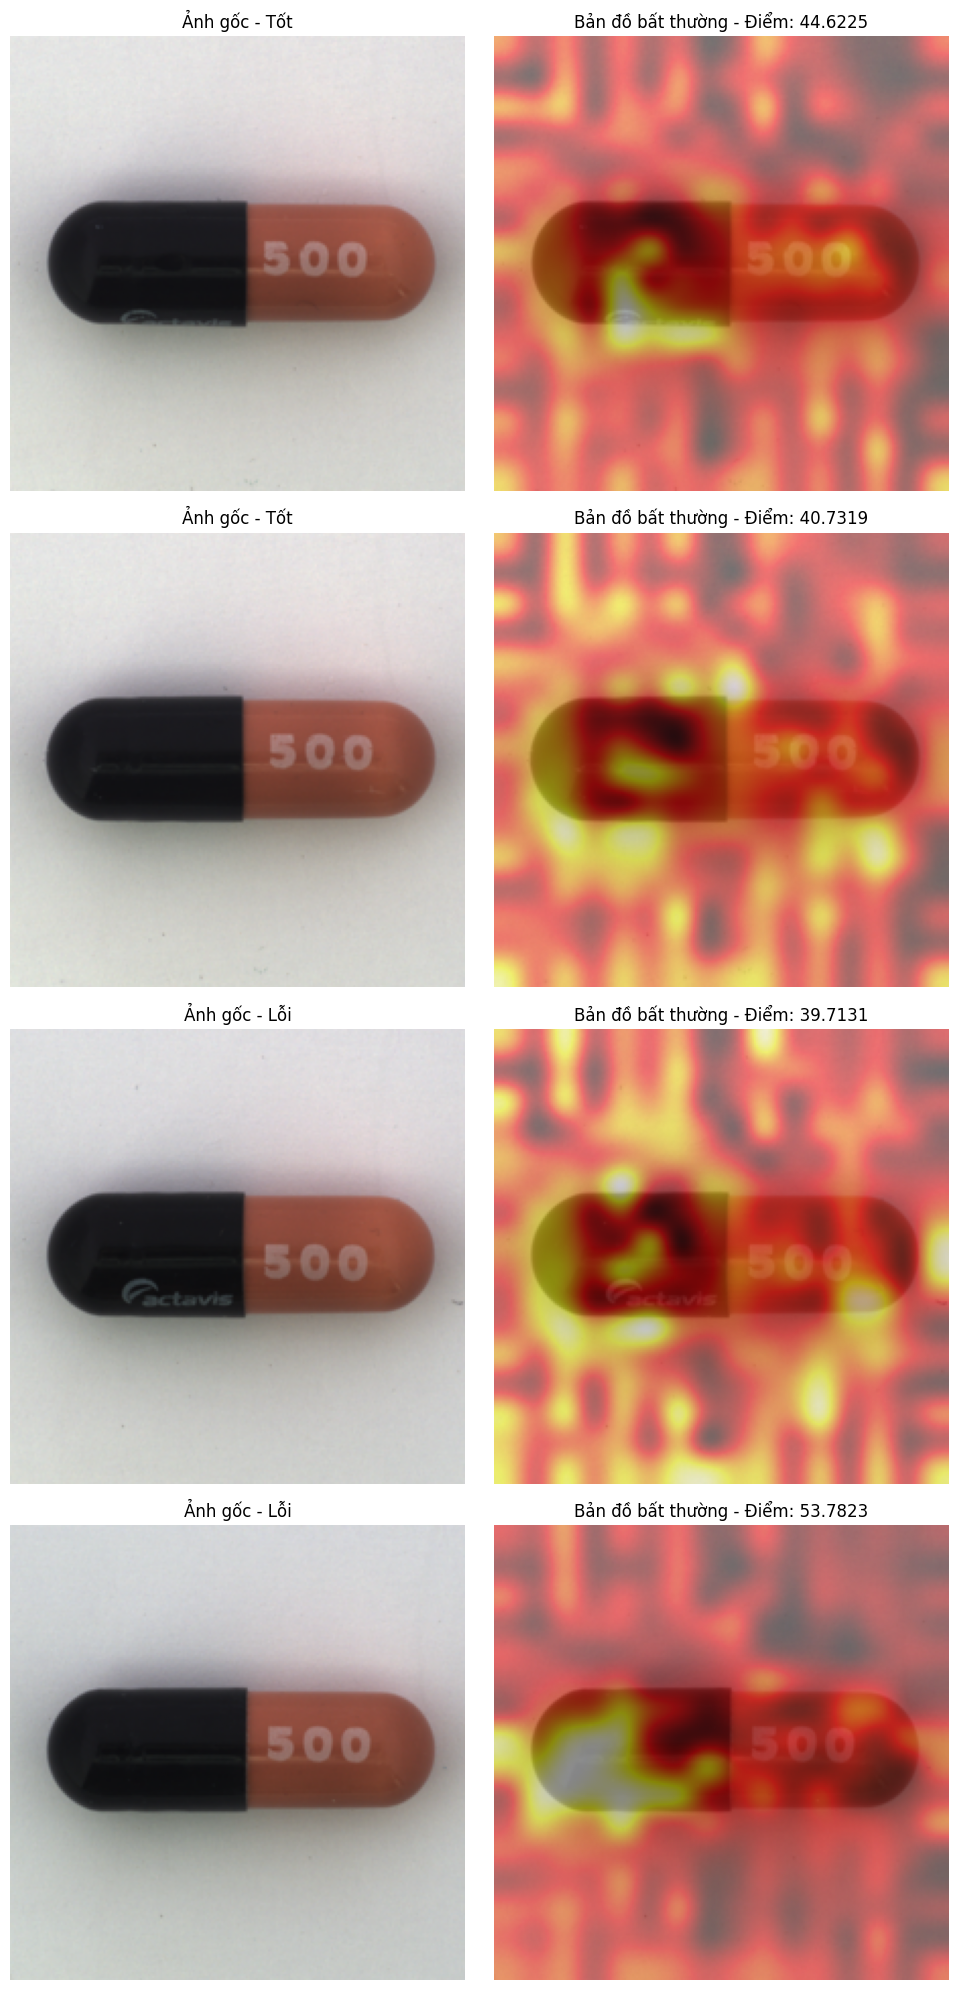


Chấm điểm bất thường hoàn tất!


In [23]:
# --- [CELL 22]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 23}
# Khởi tạo bộ chấm điểm
capsule_scorer = AnomalyScorer(capsule_memory_bank, capsule_feature_extractor, capsule_config)

# Trích xuất đặc trưng test
test_features, test_labels = capsule_feature_extractor.extract_features(capsule_test_loader)
print(f"  Kích thước đặc trưng test: {test_features.shape}")

# Tính điểm bất thường
image_scores, anomaly_maps = capsule_scorer.score_batch(test_features)

print(f"  Kích thước điểm theo ảnh: {image_scores.shape}")
print(f"  Kích thước bản đồ bất thường: {anomaly_maps.shape}")
print(f"  Miền điểm: [{image_scores.min():.4f}, {image_scores.max():.4f}]")

# Tính AUROC ở mức ảnh
binary_labels = (test_labels.numpy() > 0).astype(int)
image_auroc = roc_auc_score(binary_labels, image_scores)

print(f"\nAUROC mức ảnh: {image_auroc:.4f}")

# Trực quan hóa kết quả
normal_idx = np.where(binary_labels == 0)[0][:2]
anomaly_idx = np.where(binary_labels == 1)[0][:2]
viz_indices = np.concatenate([normal_idx, anomaly_idx])

fig, axes = plt.subplots(len(viz_indices), 2, figsize=(10, 5 * len(viz_indices)))

for i, idx in enumerate(viz_indices):
    # Nạp ảnh gốc từ đường dẫn
    img_path = capsule_train_ds.image_paths[idx]
    img = Image.open(img_path).convert('RGB')
    img = img.resize((capsule_config.img_size[1], capsule_config.img_size[0]))
    img_np = np.array(img) / 255.0
    
    # Ảnh gốc
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f'Ảnh gốc - {"Lỗi" if binary_labels[idx] else "Tốt"}')
    axes[i, 0].axis('off')
    
    # Lớp phủ bất thường
    axes[i, 1].imshow(img_np)
    axes[i, 1].imshow(anomaly_maps[idx], cmap='hot', alpha=0.5)
    axes[i, 1].set_title(f'Bản đồ bất thường - Điểm: {image_scores[idx]:.4f}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"\nChấm điểm bất thường hoàn tất!")

In [24]:
# --- [CELL 23]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 24}
from datetime import datetime
import pickle
import numpy as np

class MultiCategoryPatchCore:
    def __init__(self, config, feature_extractor):
        self.config = config
        self.feature_extractor = feature_extractor
        self.models = {}
        self.results = {}

        self.train_transform = ImageTransforms.get_train_transforms(config.img_size, config.normalize_mean, config.normalize_std)
        self.test_transform  = ImageTransforms.get_test_transforms(config.img_size, config.normalize_mean, config.normalize_std)

    def train_category(self, category):
        print(f"\n{'='*80}")
        print(f"Đang huấn luyện danh mục: {category.upper()}")
        print(f"{'='*80}")

        train_dataset = MVTecDataset(self.config.data_dir, category, "train", transform=self.train_transform)
        test_dataset  = MVTecDataset(self.config.data_dir, category, "test",  transform=self.test_transform)
        print(f"Thống kê dữ liệu: {len(train_dataset)} train, {len(test_dataset)} test")

        train_loader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=False, num_workers=self.config.num_workers)
        test_loader  = DataLoader(test_dataset,  batch_size=self.config.batch_size, shuffle=False, num_workers=self.config.num_workers)

        print("Đang trích xuất đặc trưng...")
        train_features, _ = self.feature_extractor.extract_features(train_loader)
        test_features, test_labels = self.feature_extractor.extract_features(test_loader)

        print(f"  Train: {tuple(train_features.shape)}, Test: {tuple(test_features.shape)}")

        print("Đang xây dựng memory bank...")
        mem_bank = MemoryBank(feature_dim=self.config.feature_dim, coreset_sampling_ratio=0.1)
        mem_bank.build(train_features)

        print("Đang tính điểm bất thường...")
        scorer = AnomalyScorer(mem_bank, self.feature_extractor, self.config)
        image_scores, _ = scorer.score_batch(test_features)

        # FIX: test_labels có thể là torch tensor
        y = test_labels.detach().cpu().numpy() if hasattr(test_labels, "detach") else np.asarray(test_labels)
        binary_labels = (y > 0).astype(int)

        image_auroc = roc_auc_score(binary_labels, image_scores)
        print(f"AUROC mức ảnh: {image_auroc:.4f}")

        self.models[category] = {"memory_bank": mem_bank, "scorer": scorer}
        self.results[category] = {"image_auroc": float(image_auroc), "n_train": len(train_dataset), "n_test": len(test_dataset)}
        return image_auroc

    def train_target_only(self):
        """Chạy đúng 1 category theo config.target_category."""
        if not self.config.target_category:
            raise ValueError("config.target_category đang None. Hãy set ví dụ: config.target_category='capsule'")
        return self.train_category(self.config.target_category)

    def train_all_categories(self):
        """Nếu có target_category thì chỉ chạy target, không thì chạy tất cả."""
        cats = [self.config.target_category] if self.config.target_category else self.config.categories

        print(f"\n{'='*80}")
        print("BẮT ĐẦU HUẤN LUYỆN")
        print(f"{'='*80}")
        print(f"Số danh mục sẽ chạy: {len(cats)} -> {cats}")

        start_time = datetime.now()
        for i, category in enumerate(cats, 1):
            print(f"\n[{i}/{len(cats)}] {category}")
            try:
                auroc = self.train_category(category)
                print(f"{category}: {auroc:.4f}")
            except Exception as e:
                print(f"{category}: {str(e)}")
                self.results[category] = {"image_auroc": None, "error": str(e)}

        print(f"\nHOÀN THÀNH - Thời gian: {datetime.now() - start_time}")
        self.display_results()

    def display_results(self):
        print(f"\nTỔNG HỢP KẾT QUẢ\n{'='*80}")
        print(f"{'Danh mục':<20} {'Train':<10} {'Test':<10} {'AUROC':<10}")
        print(f"{'-'*80}")

        for cat in sorted(self.results.keys()):
            res = self.results[cat]
            if "error" in res:
                print(f"{cat:<20} {'LỖI':<10} {'LỖI':<10} {'N/A':<10}")
            else:
                print(f"{cat:<20} {res['n_train']:<10} {res['n_test']:<10} {res['image_auroc']:<10.4f}")

        valid = [r["image_auroc"] for r in self.results.values() if r.get("image_auroc") is not None]
        if valid:
            print(f"{'-'*80}")
            print(f"{'TRUNG BÌNH':<20} {'':<10} {'':<10} {float(np.mean(valid)):<10.4f}")
        print(f"{'='*80}")

    def save_models(self, filename="patchcore_models.pkl"):
        save_path = self.config.model_dir / filename
        save_data = {
            "models": {cat: model["memory_bank"] for cat, model in self.models.items()},
            "results": self.results,
            "config": self.config,
        }
        with open(save_path, "wb") as f:
            pickle.dump(save_data, f)
        print(f"\nĐã lưu: {save_path} ({save_path.stat().st_size / (1024**2):.2f} MB)")

In [25]:
# --- [CELL 24]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 25}
# config.target_category = "capsule"
capsule_patchcore = MultiCategoryPatchCore(capsule_config, capsule_feature_extractor)
capsule_patchcore.train_target_only()     
capsule_patchcore.save_models("patchcore_capsule.pkl")


Đang huấn luyện danh mục: CAPSULE
Thống kê dữ liệu: 219 train, 132 test
Đang trích xuất đặc trưng...
  Train: (219, 256, 768), Test: (132, 256, 768)
Đang xây dựng memory bank...
Đang xây dựng memory bank...
  Dạng đầu vào: torch.Size([219, 256, 768])
  Dạng sau khi dàn phẳng: torch.Size([56064, 768])
  Áp dụng coreset subsampling: 56064 → 5606
  Kích thước memory bank: (5606, 768)
  Dung lượng bộ nhớ: 16.42 MB
Đang tính điểm bất thường...
AUROC mức ảnh: 0.9262

Đã lưu: models/patchcore_capsule.pkl (16.47 MB)


In [26]:
# --- [CELL 25]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 26}
# ============================================================================
# BLOCK 11: TRỰC QUAN HEATMAP BẤT THƯỜNG
# ============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F
from scipy.ndimage import gaussian_filter
from pathlib import Path

# Cấu hình
HEATMAP_CONFIG = {
    'samples_per_category': 4,  # 1 bình thường + 3 bất thường
    'colormap': 'jet',
    'overlay_alpha': 0.5,
    'gaussian_sigma': 4,
    'figsize_per_sample': (15, 5)
}

def select_representative_samples(category_name, test_results, n_samples=4):
    """
    Chọn mẫu đại diện: 1 mẫu bình thường (điểm thấp) + 3 mẫu bất thường (điểm cao, đa dạng)
    """
    results = test_results[category_name]
    
    # Tách mẫu bình thường và bất thường
    normal_indices = [i for i, label in enumerate(results['labels']) if label == 0]
    anomaly_indices = [i for i, label in enumerate(results['labels']) if label == 1]
    
    selected = []
    
    # 1 mẫu bình thường có điểm thấp nhất
    if normal_indices:
        normal_scores = [results['image_scores'][i] for i in normal_indices]
        best_normal_idx = normal_indices[np.argmin(normal_scores)]
        selected.append(best_normal_idx)
    
    # 3 mẫu bất thường với mức điểm đa dạng (cao, trung bình-cao, rất cao)
    if len(anomaly_indices) >= 3:
        anomaly_scores = [(i, results['image_scores'][i]) for i in anomaly_indices]
        anomaly_scores.sort(key=lambda x: x[1], reverse=True)
        
        # Bất thường cao nhất, bất thường trung vị, bất thường ở khoảng phân vị 75
        selected.append(anomaly_scores[0][0])  # Bất thường nặng nhất
        selected.append(anomaly_scores[len(anomaly_scores)//2][0])  # Trung vị
        selected.append(anomaly_scores[len(anomaly_scores)//4][0])  # Xấp xỉ phân vị 75
    elif anomaly_indices:
        # Nếu ít hơn 3, lấy tối đa 3 mẫu
        selected.extend(anomaly_indices[:3])
    
    return selected[:n_samples]

def generate_anomaly_heatmap(img_np_01, anomaly_map, config):
    """
    img_np_01: np.array [H,W,3] trong [0,1]
    anomaly_map: np.array [H,W]
    """
    anomaly_smooth = gaussian_filter(anomaly_map, sigma=config['gaussian_sigma'])

    if anomaly_smooth.max() > anomaly_smooth.min():
        anomaly_norm = (anomaly_smooth - anomaly_smooth.min()) / (anomaly_smooth.max() - anomaly_smooth.min())
    else:
        anomaly_norm = np.zeros_like(anomaly_smooth)

    cmap = plt.get_cmap(config['colormap'])
    heatmap_rgb = cmap(anomaly_norm)[..., :3]
    overlay = np.clip(img_np_01 * (1 - config['overlay_alpha']) + heatmap_rgb * config['overlay_alpha'], 0, 1)
    return heatmap_rgb, overlay


def visualize_category_heatmaps(category_name, test_results, test_dataset, config, img_size):
    """
    img_size: tuple (H,W) lấy từ config.img_size
    """
    sample_indices = select_representative_samples(category_name, test_results, config['samples_per_category'])
    if not sample_indices:
        print(f"Không đủ mẫu cho {category_name}")
        return

    n_samples = len(sample_indices)
    fig, axes = plt.subplots(n_samples, 3, figsize=(config['figsize_per_sample'][0], config['figsize_per_sample'][1] * n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, -1)

    results = test_results[category_name]

    for row, idx in enumerate(sample_indices):
        img_path = test_dataset.image_paths[idx]
        img = Image.open(img_path).convert('RGB').resize((img_size[1], img_size[0]))
        img_np = np.asarray(img).astype(np.float32) / 255.0

        anomaly_map = results['anomaly_maps'][idx]
        image_score = results['image_scores'][idx]
        true_label  = results['labels'][idx]
        label_text = "BÌNH THƯỜNG" if true_label == 0 else "BẤT THƯỜNG"

        heatmap_rgb, overlay = generate_anomaly_heatmap(img_np, anomaly_map, config)

        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title(f'{label_text}\nĐiểm: {float(image_score):.3f}', fontsize=10, fontweight='bold')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(heatmap_rgb)
        axes[row, 1].set_title('Bản đồ bất thường', fontsize=10)
        axes[row, 1].axis('off')

        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title('Lớp phủ', fontsize=10)
        axes[row, 2].axis('off')

    plt.suptitle(f'Danh mục: {category_name.upper()}', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

In [27]:
# --- [CELL 26]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 27}
from sklearn.metrics import confusion_matrix, classification_report, roc_curve
import seaborn as sns

class ModelEvaluator:
    """Đánh giá và trực quan hiệu năng mô hình"""
    
    def __init__(self, multi_patchcore):
        self.multi_patchcore = multi_patchcore
        self.config = multi_patchcore.config
        
    def evaluate_category(self, category):
        """Đánh giá chi tiết cho một danh mục"""

        test_transform  = ImageTransforms.get_test_transforms(self.config.img_size, self.config.normalize_mean, self.config.normalize_std)
        
        # Nạp dữ liệu test
        test_dataset = MVTecDataset(
            root_dir=self.config.data_dir,
            category=category,
            split='test',
            transform=test_transform
        )
        
        test_loader = DataLoader(
            test_dataset,
            batch_size=self.config.batch_size,
            shuffle=False,
            num_workers=self.config.num_workers
        )
        
        # Lấy các thành phần của mô hình
        model = self.multi_patchcore.models[category]
        mem_bank = model['memory_bank']
        scorer = model['scorer']
        
        # Trích xuất đặc trưng và tính điểm
        test_features, test_labels = self.multi_patchcore.feature_extractor.extract_features(test_loader)
        image_scores, anomaly_maps = scorer.score_batch(test_features)
        
        binary_labels = (test_labels.numpy() > 0).astype(int)
        
        # Tính đường cong ROC
        fpr, tpr, thresholds = roc_curve(binary_labels, image_scores)
        
        # Tìm ngưỡng tối ưu (chỉ số Youden)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds[optimal_idx]
        
        # Dự đoán theo ngưỡng tối ưu
        predictions = (image_scores >= optimal_threshold).astype(int)
        
        return {
            'image_scores': image_scores,
            'binary_labels': binary_labels,
            'predictions': predictions,
            'fpr': fpr,
            'tpr': tpr,
            'thresholds': thresholds,
            'optimal_threshold': optimal_threshold,
            'anomaly_maps': anomaly_maps,
            'test_dataset': test_dataset
        }
    
    def plot_roc_curves(self, categories=None):
        """Vẽ đường cong ROC cho nhiều danh mục"""
        
        if categories is None:
            categories = list(self.multi_patchcore.models.keys())
        
        fig, ax = plt.subplots(figsize=(10, 8))
        
        for cat in categories:
            eval_results = self.evaluate_category(cat)
            auroc = self.multi_patchcore.results[cat]['image_auroc']
            
            ax.plot(
                eval_results['fpr'],
                eval_results['tpr'],
                label=f"{cat} (AUC={auroc:.3f})",
                linewidth=2
            )
        
        # Đường chéo tham chiếu
        ax.plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên', linewidth=1)
        
        ax.set_xlabel('Tỉ lệ dương tính giả (FPR)', fontsize=12)
        ax.set_ylabel('Tỉ lệ dương tính thật (TPR)', fontsize=12)
        ax.set_title('Đường cong ROC - Đa danh mục', fontsize=14, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_auroc_comparison(self):
        """Vẽ biểu đồ cột so sánh AUROC"""
        
        categories = []
        aurocs = []
        
        for cat in sorted(self.multi_patchcore.results.keys()):
            res = self.multi_patchcore.results[cat]
            if 'error' not in res:
                categories.append(cat)
                aurocs.append(res['image_auroc'])
        
        fig, ax = plt.subplots(figsize=(12, 6))
        
        colors = ['green' if a >= 0.95 else 'orange' if a >= 0.90 else 'red' for a in aurocs]
        bars = ax.barh(categories, aurocs, color=colors, alpha=0.7, edgecolor='black')
        
        # Ghi nhãn giá trị
        for i, (bar, auroc) in enumerate(zip(bars, aurocs)):
            ax.text(
                auroc + 0.01,
                i,
                f'{auroc:.4f}',
                va='center',
                fontsize=9,
                fontweight='bold'
            )
        
        # Vẽ đường trung bình
        avg_auroc = np.mean(aurocs)
        ax.axvline(
            avg_auroc,
            color='blue',
            linestyle='--',
            linewidth=2,
            label=f'Trung bình: {avg_auroc:.4f}'
        )
        
        ax.set_xlabel('Điểm AUROC', fontsize=12)
        ax.set_title('AUROC mức ảnh theo danh mục', fontsize=14, fontweight='bold')
        ax.set_xlim([0.7, 1.05])
        ax.legend()
        ax.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def visualize_predictions(self, category, n_samples=4):
        """Trực quan dự đoán cho một danh mục"""
        
        print(f"\nĐang trực quan dự đoán cho: {category}")
        
        eval_results = self.evaluate_category(category)
        
        # Chọn mẫu: 2 đúng, 2 sai (nếu có)
        correct_idx = np.where(eval_results['predictions'] == eval_results['binary_labels'])[0]
        incorrect_idx = np.where(eval_results['predictions'] != eval_results['binary_labels'])[0]
        
        n_correct = min(2, len(correct_idx))
        n_incorrect = min(n_samples - n_correct, len(incorrect_idx))
        
        viz_indices = np.concatenate([
            np.random.choice(correct_idx, n_correct, replace=False),
            np.random.choice(incorrect_idx, n_incorrect, replace=False) if len(incorrect_idx) > 0 else []
        ]).astype(int)
        
        fig, axes = plt.subplots(len(viz_indices), 2, figsize=(10, 5 * len(viz_indices)))
        if len(viz_indices) == 1:
            axes = axes.reshape(1, -1)
        
        for i, idx in enumerate(viz_indices):
            # Nạp ảnh
            img_path = eval_results['test_dataset'].image_paths[idx]
            img = Image.open(img_path).convert('RGB')
            img = img.resize((self.config.img_size[1], self.config.img_size[0]))
            img_np = np.array(img) / 255.0
            
            true_label = eval_results['binary_labels'][idx]
            pred_label = eval_results['predictions'][idx]
            score = eval_results['image_scores'][idx]
            
            # Ảnh gốc
            axes[i, 0].imshow(img_np)
            axes[i, 0].set_title(
                f"Thật: {'Lỗi' if true_label else 'Tốt'} | "
                f"Dự đoán: {'Lỗi' if pred_label else 'Tốt'} | "
                f"Điểm: {score:.3f}"
            )
            axes[i, 0].axis('off')
            
            # Lớp phủ heatmap
            axes[i, 1].imshow(img_np)
            axes[i, 1].imshow(eval_results['anomaly_maps'][idx], cmap='hot', alpha=0.5)
            axes[i, 1].set_title('Heatmap bất thường')
            axes[i, 1].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def generate_report(self):
        """Tạo báo cáo đánh giá tổng hợp"""
        
        print(f"\n{'='*80}")
        print(f"BÁO CÁO ĐÁNH GIÁ TỔNG HỢP")
        print(f"{'='*80}\n")
        
        # Thống kê tổng quan
        total_categories = len(self.multi_patchcore.results)
        successful = sum(1 for r in self.multi_patchcore.results.values() if 'error' not in r)
        
        print(f"Tổng số danh mục: {total_categories}")
        print(f"Huấn luyện thành công: {successful}")
        print(f"Thất bại: {total_categories - successful}\n")
        
        # Thống kê AUROC
        aurocs = [r['image_auroc'] for r in self.multi_patchcore.results.values() if 'error' not in r]
        
        print(f"Thống kê AUROC:")
        print(f"  Trung bình:  {np.mean(aurocs):.4f}")
        print(f"  Trung vị:    {np.median(aurocs):.4f}")
        print(f"  Độ lệch chuẩn:{np.std(aurocs):.4f}")
        print(f"  Nhỏ nhất:    {np.min(aurocs):.4f}")
        print(f"  Lớn nhất:    {np.max(aurocs):.4f}\n")
        
        # Phân nhóm theo hiệu năng
        excellent = sum(1 for a in aurocs if a >= 0.95)
        good = sum(1 for a in aurocs if 0.90 <= a < 0.95)
        needs_improvement = sum(1 for a in aurocs if a < 0.90)
        
        print(f"Phân nhóm hiệu năng:")
        print(f"  Rất tốt (≥0.95):  {excellent} danh mục")
        print(f"  Tốt (0.90-0.95):  {good} danh mục")
        print(f"  Cần cải thiện (<0.90): {needs_improvement} danh mục")
        
        print(f"\n{'='*80}")

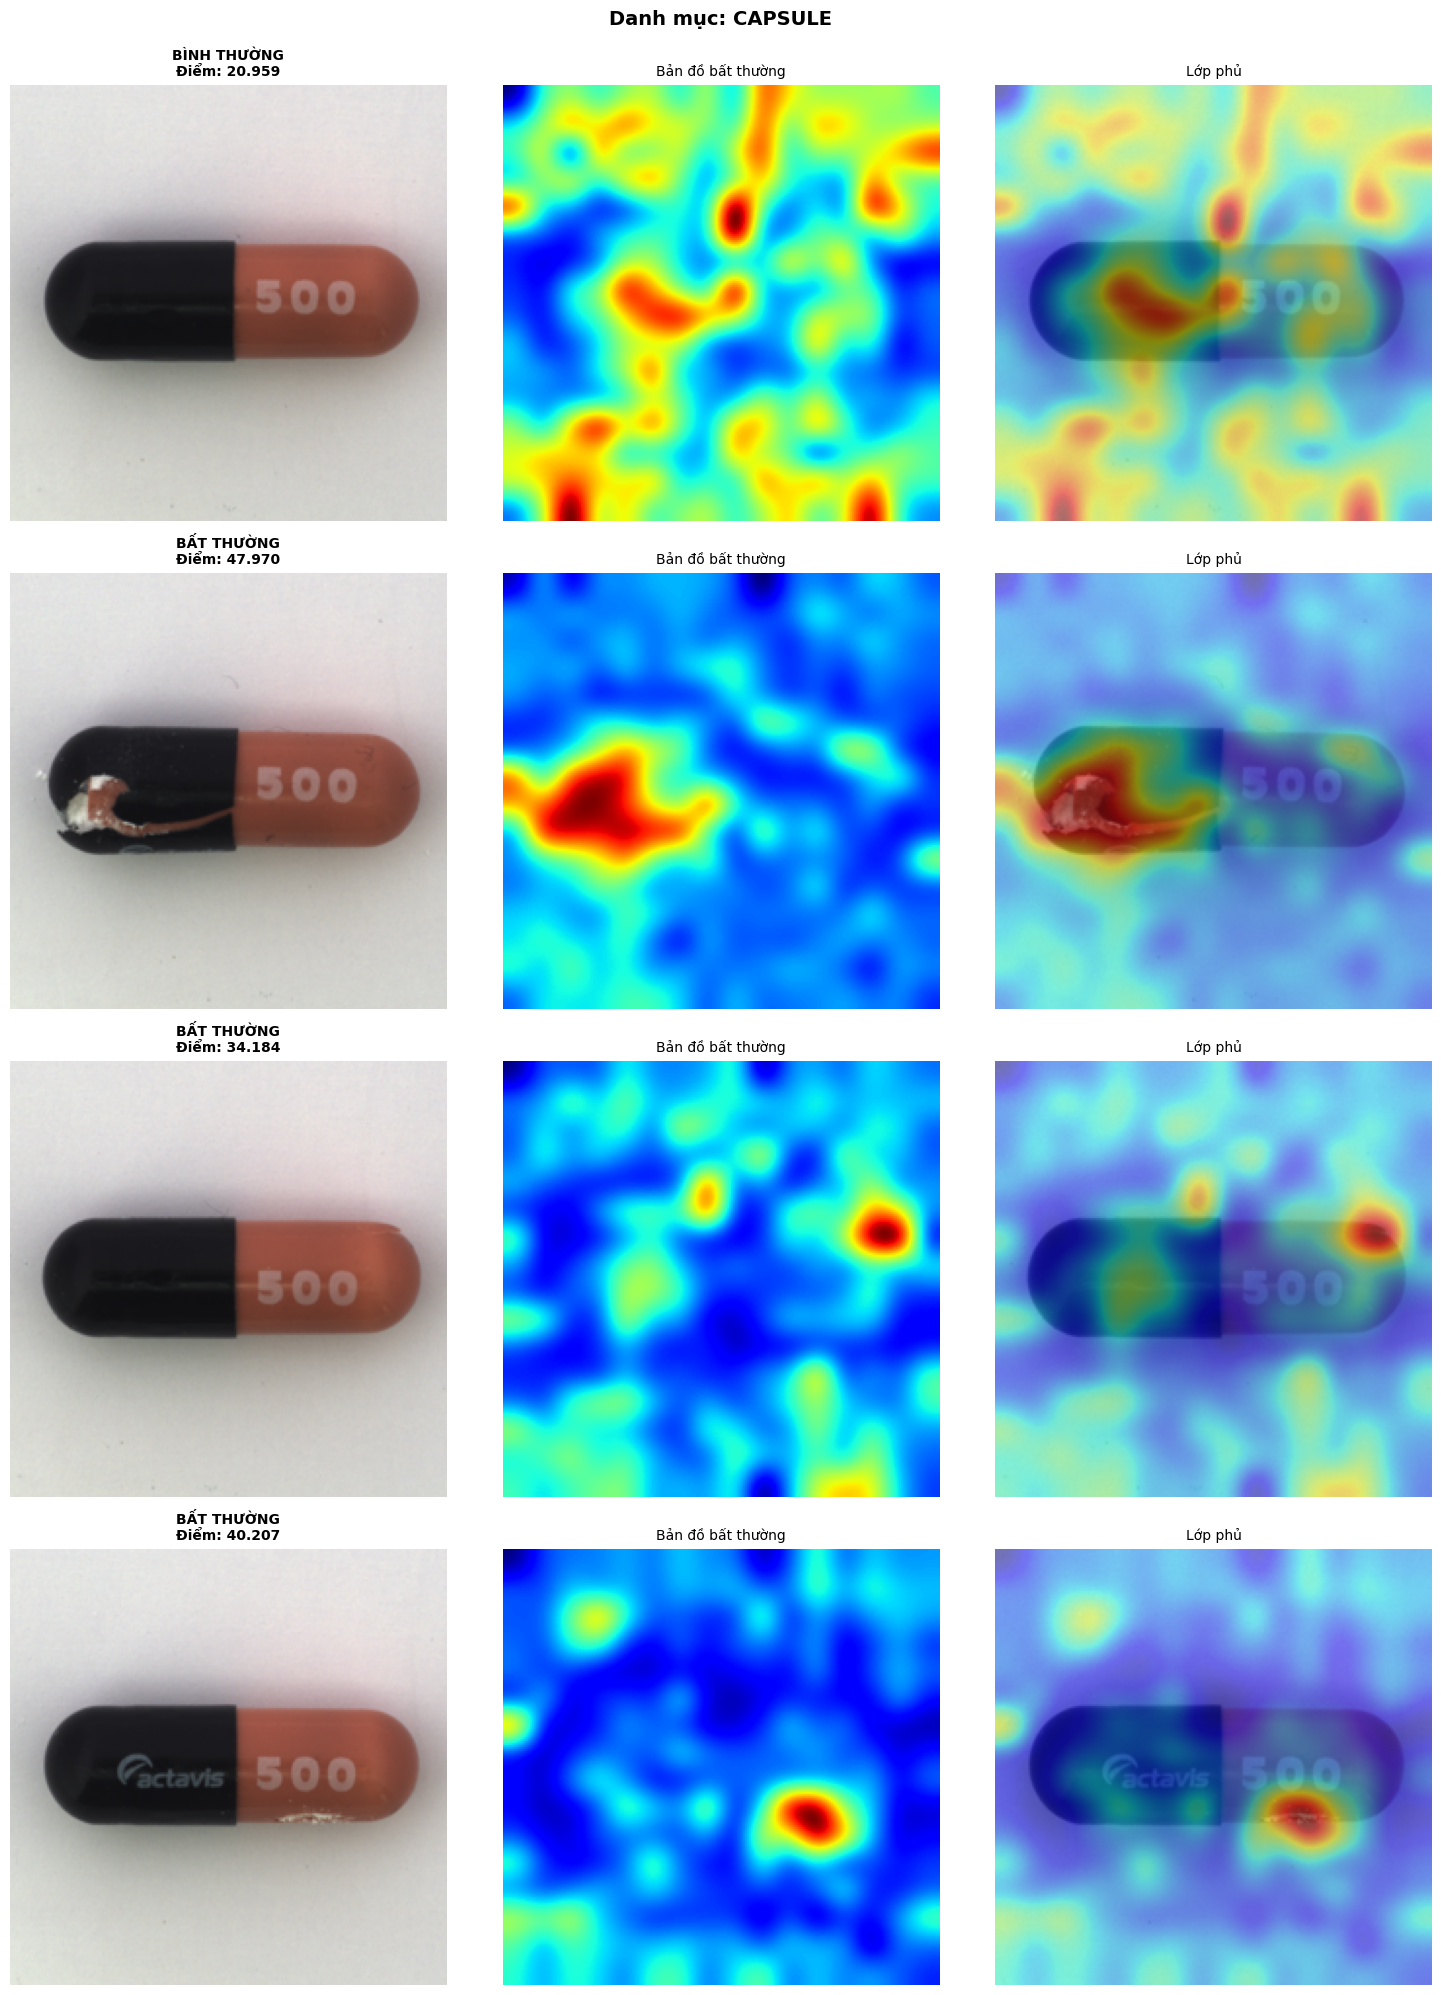

In [28]:
# --- [CELL 27]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 28}
img_size = capsule_patchcore.config.img_size       # ví dụ (224,224)
evaluator = ModelEvaluator(capsule_patchcore)

# lấy kết quả đánh giá (score + anomaly_maps + labels + test_dataset)
eval_results = evaluator.evaluate_category("capsule")

# chuẩn bị đúng format cho Block 11
test_results = {
    "capsule": {
        "image_scores": eval_results["image_scores"],
        "labels": eval_results["binary_labels"],
        "anomaly_maps": eval_results["anomaly_maps"],
    }
}

# gọi hàm visualize
visualize_category_heatmaps(
    category_name="capsule",
    test_results=test_results,
    test_dataset=eval_results["test_dataset"],
    config=HEATMAP_CONFIG,
    img_size=img_size,
)

In [29]:
# --- [CELL 28]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 29}
# === BEFORE (original) ===
# # ============================================================================
# # BLOCK 15 (FULL, MINIMAL): BENCHMARK PHÂN RÃ THỜI GIAN SUY LUẬN (1 MODEL / 1 CATEGORY)
# # - Có đủ 3 cột: Feature | Scoring | End-to-end + FPS + MemoryBank
# # - Không so sánh nhiều model, không plot rườm rà
# # ============================================================================
# 
# import time
# import numpy as np
# import torch
# import psutil
# import pandas as pd
# from torch.utils.data import DataLoader
# 
# # -----------------------
# # Helpers: memory
# # -----------------------
# def process_rss_mb() -> float:
#     """CPU RSS memory (MB) của process."""
#     return psutil.Process().memory_info().rss / 1024 / 1024
# 
# def gpu_alloc_mb() -> float:
#     """GPU allocated memory (MB) theo torch (nếu có CUDA)."""
#     return (torch.cuda.memory_allocated() / 1024 / 1024) if torch.cuda.is_available() else 0.0
# 
# 
# # -----------------------
# # Benchmark (1 category)
# # -----------------------
# class SingleCategoryBenchmark:
#     """
#     Benchmark inference đúng pipeline PatchCore bạn đang dùng:
#       - feature_extractor(images) -> patch tokens
#       - scorer.score_batch(feats.cpu()) -> scoring thật (kNN + upsample + max)
# 
#     Yêu cầu tồn tại:
#       - patchcore.config (data_dir, img_size, normalize_mean/std, batch_size...)
#       - patchcore.feature_extractor (callable: feature_extractor(images) -> [B,Np,D])
#       - patchcore.models[category]['scorer'] và ['memory_bank']
#       - MVTecDataset, ImageTransforms, DataLoader
#     """
# 
#     def __init__(self, patchcore, device=None):
#         self.patchcore = patchcore
#         self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 
#     @staticmethod
#     def _sync():
#         if torch.cuda.is_available():
#             torch.cuda.synchronize()
# 
#     def _memory_bank_mb(self, category: str) -> float:
#         mem_bank_obj = self.patchcore.models[category]["memory_bank"]
#         mem_bank_array = mem_bank_obj.memory_bank if hasattr(mem_bank_obj, "memory_bank") else mem_bank_obj
#         return float(mem_bank_array.nbytes / 1024 / 1024)
# 
#     def run(self, category: str, n_samples: int = 50, warmup: int = 5) -> dict:
#         if category[0] not in self.patchcore.models:
#             raise ValueError(
#                 f"Category '{category}' chưa được train trong patchcore.models. "
#                 f"Available: {list(self.patchcore.models.keys())}"
#             )
# 
#         cfg = self.patchcore.config
# 
#         # Transform đúng config
#         test_transform = ImageTransforms.get_test_transforms(cfg.img_size, cfg.normalize_mean, cfg.normalize_std)
# 
#         # Dataset/Loader
#         test_dataset = MVTecDataset(
#             root_dir=cfg.data_dir,
#             category=category,
#             split="test",
#             transform=test_transform,
#         )
#         test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)
# 
#         scorer = self.patchcore.models[category]["scorer"]
# 
#         # -----------------------
#         # Warmup (chạy thật)
#         # -----------------------
#         it = iter(test_loader)
#         for _ in range(min(warmup, len(test_dataset))):
#             batch = next(it)
#             images = batch["image"].to(self.device)
# 
#             with torch.no_grad():
#                 feats = self.patchcore.feature_extractor(images)  # [1, Np, D]
#                 _ = scorer.score_batch(feats.cpu())               # scoring thật (CPU/Numpy pipeline hiện tại)
#             self._sync()
# 
#         # -----------------------
#         # Timing
#         # -----------------------
#         feat_ms, score_ms, e2e_ms = [], [], []
# 
#         for i, batch in enumerate(test_loader):
#             if i >= n_samples:
#                 break
# 
#             images = batch["image"].to(self.device)
# 
#             self._sync()
#             t0 = time.perf_counter()
# 
#             # 1) Feature extraction
#             self._sync()
#             tf0 = time.perf_counter()
#             with torch.no_grad():
#                 feats = self.patchcore.feature_extractor(images)  # [1, Np, D]
#             self._sync()
#             tf1 = time.perf_counter()
# 
#             # 2) Scoring
#             ts0 = time.perf_counter()
#             with torch.no_grad():
#                 _scores, _maps = scorer.score_batch(feats.cpu())
#             ts1 = time.perf_counter()
# 
#             self._sync()
#             t1 = time.perf_counter()
# 
#             feat_ms.append((tf1 - tf0) * 1000.0)
#             score_ms.append((ts1 - ts0) * 1000.0)
#             e2e_ms.append((t1 - t0) * 1000.0)
# 
#         if len(score_ms) == 0:
#             raise RuntimeError("score_ms rỗng -> scoring chưa chạy (kiểm tra loop/loader/n_samples).")
# 
#         feat_ms = np.asarray(feat_ms, dtype=np.float64)
#         score_ms = np.asarray(score_ms, dtype=np.float64)
#         e2e_ms = np.asarray(e2e_ms, dtype=np.float64)
# 
#         # Memory
#         mem_bank_mb = self._memory_bank_mb(category)
#         cpu_rss = process_rss_mb()
#         gpu_mem = gpu_alloc_mb()
# 
#         # Result dict
#         result = {
#             "category": category,
#             "device": str(self.device),
#             "n_samples": int(len(e2e_ms)),
#             "timing": {
#                 "feature_mean_ms": float(feat_ms.mean()),
#                 "feature_p50_ms": float(np.median(feat_ms)),
#                 "feature_min_ms": float(feat_ms.min()),
#                 "feature_max_ms": float(feat_ms.max()),
# 
#                 "scoring_mean_ms": float(score_ms.mean()),
#                 "scoring_p50_ms": float(np.median(score_ms)),
#                 "scoring_min_ms": float(score_ms.min()),
#                 "scoring_max_ms": float(score_ms.max()),
# 
#                 "e2e_mean_ms": float(e2e_ms.mean()),
#                 "e2e_p50_ms": float(np.median(e2e_ms)),
#                 "e2e_min_ms": float(e2e_ms.min()),
#                 "e2e_max_ms": float(e2e_ms.max()),
#                 "fps_mean": float(1000.0 / e2e_ms.mean()),
#             },
#             "memory": {
#                 "memory_bank_mb": float(mem_bank_mb),
#                 "process_cpu_rss_mb": float(cpu_rss),
#                 "gpu_allocated_mb": float(gpu_mem),
#             },
#             # optional debug arrays (comment out if không cần)
#             "raw_ms": {
#                 "feature_ms": feat_ms,
#                 "scoring_ms": score_ms,
#                 "e2e_ms": e2e_ms,
#             },
#         }
#         return result
# 
# 
# # -----------------------
# # Pretty print (phân rã theo CỘT)
# # -----------------------
# def show_benchmark_table(result: dict):
#     t = result["timing"]
#     m = result["memory"]
# 
#     df = pd.DataFrame([{
#         "Category": result["category"],
#         "Device": result["device"],
#         "N": result["n_samples"],
#         "Feature (ms)": round(t["feature_mean_ms"], 3),
#         "Scoring (ms)": round(t["scoring_mean_ms"], 3),
#         "End-to-end (ms)": round(t["e2e_mean_ms"], 3),
#         "FPS": round(t["fps_mean"], 2),
#         "MemBank (MB)": round(m["memory_bank_mb"], 2),
#         "CPU RSS (MB)": round(m["process_cpu_rss_mb"], 2),
#         "GPU alloc (MB)": round(m["gpu_allocated_mb"], 2) if torch.cuda.is_available() else 0.0,
#     }])
# 
#     print("=" * 80)
#     print("BENCHMARK (1 MODEL / 1 CATEGORY) - PHÂN RÃ THỜI GIAN")
#     print("=" * 80)
#     display(df)
# 
#     # sanity check quick
#     print("-" * 80)
#     print(f"Feature median: {t['feature_p50_ms']:.3f} ms | Scoring median: {t['scoring_p50_ms']:.3f} ms | E2E median: {t['e2e_p50_ms']:.3f} ms")
#     print("=" * 80)
# 
# 
# # -----------------------
# # RUN (Bạn chỉnh 2 dòng này)
# # -----------------------
# # NOTE: patchcore phải là object bạn đã train_target_only() xong.
# # Ví dụ: patchcore = patchcore_capsule
# 
# # category = patchcore.config.target_category or "capsule"
# # bench = SingleCategoryBenchmark(patchcore)
# # result = bench.run(category, n_samples=50, warmup=5)
# # show_benchmark_table(result)

# === AFTER (edited) ===
import time
import numpy as np
import torch
import psutil
import pandas as pd
from torch.utils.data import DataLoader


def process_rss_mb() -> float:
    """CPU RSS memory (MB) của process."""
    return psutil.Process().memory_info().rss / 1024 / 1024

def gpu_alloc_mb() -> float:
    """GPU allocated memory (MB) theo torch (nếu có CUDA)."""
    return (torch.cuda.memory_allocated() / 1024 / 1024) if torch.cuda.is_available() else 0.0


class SingleCategoryBenchmark:
    """
    Benchmark inference đúng pipeline PatchCore bạn đang dùng:
      - feature_extractor(images) -> patch tokens
      - scorer.score_batch(feats.cpu()) -> scoring thật (kNN + upsample + max)

    Yêu cầu tồn tại:
      - patchcore.config (data_dir, img_size, normalize_mean/std, batch_size...)
      - patchcore.feature_extractor (callable: feature_extractor(images) -> [B,Np,D])
      - patchcore.models[category]['scorer'] và ['memory_bank']
      - MVTecDataset, ImageTransforms, DataLoader
    """

    def __init__(self, patchcore, device=None):
        self.patchcore = patchcore
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    @staticmethod
    def _sync():
        if torch.cuda.is_available():
            torch.cuda.synchronize()

    def _memory_bank_mb(self, category: str) -> float:
        mem_bank_obj = self.patchcore.models[category]["memory_bank"]
        mem_bank_array = mem_bank_obj.memory_bank if hasattr(mem_bank_obj, "memory_bank") else mem_bank_obj
        return float(mem_bank_array.nbytes / 1024 / 1024)

    def run(self, category: str, n_samples: int = 50, warmup: int = 5) -> dict:
        # category phải là chuỗi tên category, kiểm tra trực tiếp theo key
        if category not in self.patchcore.models:
            raise ValueError(
                f"Category '{category}' chưa được train trong patchcore.models. "
                f"Available: {list(self.patchcore.models.keys())}"
            )

        cfg = self.patchcore.config

        test_transform = ImageTransforms.get_test_transforms(cfg.img_size, cfg.normalize_mean, cfg.normalize_std)

        test_dataset = MVTecDataset(
            root_dir=cfg.data_dir,
            category=category,
            split="test",
            transform=test_transform,
        )
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

        scorer = self.patchcore.models[category]["scorer"]

        it = iter(test_loader)
        for _ in range(min(warmup, len(test_dataset))):
            batch = next(it)
            images = batch["image"].to(self.device)

            with torch.no_grad():
                feats = self.patchcore.feature_extractor(images)
                _ = scorer.score_batch(feats.cpu())
            self._sync()

        feat_ms, score_ms, e2e_ms = [], [], []

        for i, batch in enumerate(test_loader):
            if i >= n_samples:
                break

            images = batch["image"].to(self.device)

            self._sync()
            t0 = time.perf_counter()

            self._sync()
            tf0 = time.perf_counter()
            with torch.no_grad():
                feats = self.patchcore.feature_extractor(images)
            self._sync()
            tf1 = time.perf_counter()

            ts0 = time.perf_counter()
            with torch.no_grad():
                _scores, _maps = scorer.score_batch(feats.cpu())
            ts1 = time.perf_counter()

            self._sync()
            t1 = time.perf_counter()

            feat_ms.append((tf1 - tf0) * 1000.0)
            score_ms.append((ts1 - ts0) * 1000.0)
            e2e_ms.append((t1 - t0) * 1000.0)

        if len(score_ms) == 0:
            raise RuntimeError("score_ms rỗng -> scoring chưa chạy (kiểm tra loop/loader/n_samples).")

        feat_ms = np.asarray(feat_ms, dtype=np.float64)
        score_ms = np.asarray(score_ms, dtype=np.float64)
        e2e_ms = np.asarray(e2e_ms, dtype=np.float64)

        mem_bank_mb = self._memory_bank_mb(category)
        cpu_rss = process_rss_mb()
        gpu_mem = gpu_alloc_mb()

        result = {
            "category": category,
            "device": str(self.device),
            "n_samples": int(len(e2e_ms)),
            "timing": {
                "feature_mean_ms": float(feat_ms.mean()),
                "feature_p50_ms": float(np.median(feat_ms)),
                "feature_min_ms": float(feat_ms.min()),
                "feature_max_ms": float(feat_ms.max()),
                "scoring_mean_ms": float(score_ms.mean()),
                "scoring_p50_ms": float(np.median(score_ms)),
                "scoring_min_ms": float(score_ms.min()),
                "scoring_max_ms": float(score_ms.max()),
                "e2e_mean_ms": float(e2e_ms.mean()),
                "e2e_p50_ms": float(np.median(e2e_ms)),
                "e2e_min_ms": float(e2e_ms.min()),
                "e2e_max_ms": float(e2e_ms.max()),
                "fps_mean": float(1000.0 / e2e_ms.mean()),
            },
            "memory": {
                "memory_bank_mb": float(mem_bank_mb),
                "process_cpu_rss_mb": float(cpu_rss),
                "gpu_allocated_mb": float(gpu_mem),
            },
            "raw_ms": {
                "feature_ms": feat_ms,
                "scoring_ms": score_ms,
                "e2e_ms": e2e_ms,
            },
        }
        return result


def show_benchmark_table(result: dict):
    t = result["timing"]
    m = result["memory"]

    df = pd.DataFrame([{
        "Category": result["category"],
        "Device": result["device"],
        "N": result["n_samples"],
        "Feature (ms)": round(t["feature_mean_ms"], 3),
        "Scoring (ms)": round(t["scoring_mean_ms"], 3),
        "End-to-end (ms)": round(t["e2e_mean_ms"], 3),
        "FPS": round(t["fps_mean"], 2),
        "MemBank (MB)": round(m["memory_bank_mb"], 2),
        "CPU RSS (MB)": round(m["process_cpu_rss_mb"], 2),
        "GPU alloc (MB)": round(m["gpu_allocated_mb"], 2) if torch.cuda.is_available() else 0.0,
    }])

    print("=" * 80)
    print("BENCHMARK (1 MODEL / 1 CATEGORY) - PHÂN RÃ THỜI GIAN")
    print("=" * 80)
    display(df)

    print("-" * 80)
    print(f"Feature median: {t['feature_p50_ms']:.3f} ms | Scoring median: {t['scoring_p50_ms']:.3f} ms | E2E median: {t['e2e_p50_ms']:.3f} ms")
    print("=" * 80)

In [30]:
# --- [CELL 29]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 30}
# === BEFORE (original) ===
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# benchmark = SingleCategoryBenchmark(capsule_patchcore, device)
# benchmark.run(capsule_config.categories, n_samples=50)
# 
# # Tạo trực quan
# plot_timing_breakdown(benchmark.results)
# plot_fps_comparison(benchmark.results)
# plot_memory_usage(benchmark.results)
# 
# # Tạo báo cáo thống kê
# generate_benchmark_report(benchmark.results)

# === AFTER (edited) ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
benchmark = SingleCategoryBenchmark(capsule_patchcore, device)

# categories là list, benchmark.run cần 1 chuỗi category
result = benchmark.run(capsule_config.target_category, n_samples=50)
show_benchmark_table(result)

BENCHMARK (1 MODEL / 1 CATEGORY) - PHÂN RÃ THỜI GIAN


,Category,Device,N,Feature (ms),Scoring (ms),End-to-end (ms),FPS,MemBank (MB),CPU RSS (MB),GPU alloc (MB)
0,capsule,cpu,50,1316.805,98.394,1415.23,0.71,16.42,1333.82,0.0


--------------------------------------------------------------------------------
Feature median: 1485.379 ms | Scoring median: 106.669 ms | E2E median: 1589.783 ms


In [31]:
import numpy as np
import torch

# Preconditions
assert "SingleCategoryBenchmark" in globals(), "SingleCategoryBenchmark class is missing"
assert "capsule_patchcore" in globals(), "capsule_patchcore should exist from previous cells"
assert "capsule_config" in globals(), "capsule_config should exist from previous cells"
assert isinstance(capsule_config.target_category, str), "fix 1: target_category must be a string"

# Build benchmark object if not already created
if "benchmark" not in globals() or not isinstance(benchmark, SingleCategoryBenchmark):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    benchmark = SingleCategoryBenchmark(capsule_patchcore, device)

# run() must work when category is a plain string (not indexed as category[0])
category = capsule_config.target_category
assert category in capsule_patchcore.models, f"Category '{category}' not found in trained models"

# Smoke run (small) to keep test lightweight
result = benchmark.run(category, n_samples=1, warmup=0)

# Validate result structure/content
assert isinstance(result, dict), "benchmark.run should return a dict"
for k in ("category", "device", "n_samples", "timing", "memory"):
    assert k in result, f"Missing key in benchmark result: {k}"

assert result["category"] == category, "Returned category mismatch"
assert result["n_samples"] >= 1, "Expected at least 1 processed sample"

timing = result["timing"]
memory = result["memory"]

for k in ("feature_mean_ms", "scoring_mean_ms", "e2e_mean_ms", "fps_mean"):
    assert k in timing, f"Missing timing metric: {k}"
    assert np.isfinite(float(timing[k])), f"Timing metric is not finite: {k}"

for k in ("memory_bank_mb", "process_cpu_rss_mb", "gpu_allocated_mb"):
    assert k in memory, f"Missing memory metric: {k}"
    assert np.isfinite(float(memory[k])), f"Memory metric is not finite: {k}"